In [1]:
from pathlib import Path
import os
import sys

# move working directory to project root (parent of notebooks)
project_root = Path.cwd().parent
os.chdir(project_root)

# ensure imports work
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Working directory:", Path.cwd())

Working directory: /Users/ourmangg/Documents/Personal_Project/LLMAgora


# Aggregate analysis

## Load data

Set **`SWEEPS`** in the code cell below to either

- a single int (e.g. `7`) to load `outputs/Sweep_7/aggregate_df.pkl`, or
- a list of ints (e.g. `[6, 7]`) to union across sweeps.

When multiple sweeps contain the same experiment row (same model + scenario + incentive direction + type), the row with the **higher `repeat_count`** wins; ties are broken by the later sweep, and every conflict is printed. All figures across sweeps are saved to a single shared folder, `outputs/saved_plots/`, with descriptive filenames that encode scenario, model, incentive direction/type, and repeat.


In [2]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

# --- Sweep selection --------------------------------------------------------
# Set SWEEPS to a single int for one sweep, or a list/tuple of ints to union
# across sweeps. When multiple sweeps contain the same experiment row (same
# model + scenario_id + incentive_direction + incentive_type), the row with
# the higher repeat_count wins; on a tie, the later sweep wins. Every
# conflict is reported on stdout.
SWEEPS = [6,7]  # e.g. [6, 7]

if isinstance(SWEEPS, (int, np.integer)):
    _sweep_list = [int(SWEEPS)]
else:
    _sweep_list = [int(s) for s in SWEEPS]
if not _sweep_list:
    raise ValueError("SWEEPS must be a non-empty int or list of ints")

# Use the max sweep in the list as the primary one for locating per-sweep
# artifacts (e.g. aggregate_df.pkl). All plots, regardless of sweep, are
# written to a single shared folder: outputs/saved_plots.
SWEEP = max(_sweep_list)
SWEEP_DIR = Path(f"outputs/Sweep_{SWEEP}")
AGGREGATE_PKL = SWEEP_DIR / "aggregate_df.pkl"
SAVED_PLOTS_DIR = Path("outputs/saved_plots")

_DEDUP_KEY = ["model", "scenario_id", "incentive_direction", "incentive_type"]


def _load_and_union_sweeps(sweeps: list[int]) -> tuple[pd.DataFrame, list[dict]]:
    """Load each sweep's aggregate_df.pkl and union on _DEDUP_KEY.

    Conflict resolution: highest repeat_count wins; ties broken by later sweep.
    Returns (df, conflicts) where `conflicts` is one dict per resolved conflict.
    """
    frames = []
    for s in sweeps:
        pkl = Path(f"outputs/Sweep_{s}/aggregate_df.pkl")
        with pkl.open("rb") as f:
            df_s = pickle.load(f)
        df_s = df_s.copy()
        df_s["_sweep"] = s
        frames.append(df_s)
    combined = pd.concat(frames, ignore_index=True)

    # Sort so the winner of each duplicate group is first:
    #   group keys ASC, repeat_count DESC, _sweep DESC
    sort_cols = _DEDUP_KEY + ["repeat_count", "_sweep"]
    ascending = [True] * len(_DEDUP_KEY) + [False, False]
    combined = combined.sort_values(sort_cols, ascending=ascending, kind="stable").reset_index(drop=True)

    conflicts: list[dict] = []
    dup_mask = combined.duplicated(subset=_DEDUP_KEY, keep=False)
    if dup_mask.any():
        for key_vals, group in combined.loc[dup_mask].groupby(_DEDUP_KEY, sort=False):
            winner = group.iloc[0]
            losers = group.iloc[1:]
            conflicts.append({
                **dict(zip(_DEDUP_KEY, key_vals)),
                "winner_sweep": int(winner["_sweep"]),
                "winner_repeat_count": int(winner["repeat_count"]),
                "loser_sweeps": [int(r["_sweep"]) for _, r in losers.iterrows()],
                "loser_repeat_counts": [int(r["repeat_count"]) for _, r in losers.iterrows()],
            })

    deduped = combined.drop_duplicates(subset=_DEDUP_KEY, keep="first").reset_index(drop=True)
    deduped = deduped.drop(columns=["_sweep"])
    return deduped, conflicts


aggregate_df, _conflicts = _load_and_union_sweeps(_sweep_list)

if len(_sweep_list) == 1:
    print(f"Loaded Sweep_{_sweep_list[0]}: {len(aggregate_df)} rows.")
else:
    print(f"Loaded sweeps {_sweep_list}: {len(aggregate_df)} unique rows after union.")
    if _conflicts:
        print(
            f"Resolved {len(_conflicts)} conflict(s) by keeping highest repeat_count "
            f"(ties broken by later sweep):"
        )
        for c in _conflicts:
            losers = ", ".join(
                f"Sweep_{s} (rc={rc})"
                for s, rc in zip(c["loser_sweeps"], c["loser_repeat_counts"])
            )
            print(
                f"  {c['model']} | {c['scenario_id']} | "
                f"{c['incentive_direction']}/{c['incentive_type']}"
                f" -> winner Sweep_{c['winner_sweep']} (rc={c['winner_repeat_count']}); "
                f"dropped {losers}"
            )
    else:
        print("No conflicts across sweeps.")


Loaded sweeps [6, 7]: 60 unique rows after union.
No conflicts across sweeps.


In [3]:
# Shared friendly model-name mapping — used by all plotting cells below.
_FRIENDLY_MODEL_NAMES = {
    "anthropic/claude-opus-4.6": "Claude Opus 4.6",
    "deepseek/deepseek-v3.2": "DeepSeek V3.2",
    "google/gemini-3.1-flash-lite-preview": "Gemini 3.1 Flash-Lite",
    "google/gemini-3.1-pro-preview": "Gemini 3.1 Pro",
    "openai/gpt-5.4": "GPT-5.4",
    "openai/gpt-oss-120b": "GPT-OSS-120B",
    "qwen/qwen3.5-397b-a17b": "Qwen 3.5 397B",
    "x-ai/grok-4": "Grok 4",
    "z-ai/glm-5": "GLM-5",
}


def friendly_model(raw: str) -> str:
    """Return human-readable model name, falling back to the part after '/'."""
    return _FRIENDLY_MODEL_NAMES.get(raw, raw.split("/")[-1] if "/" in raw else raw)


### Dataset overview


In [4]:
print("Loaded:", AGGREGATE_PKL.resolve())
print("Shape:", aggregate_df.shape)
print("Columns:", list(aggregate_df.columns))


Loaded: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/Sweep_7/aggregate_df.pkl
Shape: (60, 36)
Columns: ['experiment_index', 'config_fingerprint', 'repeat_count', 'case_ids', 'model', 'incentive_direction', 'incentive_type', 'scenario_id', 'cosine-similarity-self-consistency', 'cosine-similarity-cross-agent-alignment', 'cosine-similarity-self-consistency-all-repeats', 'cosine-similarity-cross-agent-alignment-all-repeats', 'persona-individual-turn-scores', 'persona-cumulative-scores', 'persona-full-debate-scores', 'persona-individual-turn-scores-all-repeats', 'persona-cumulative-scores-all-repeats', 'persona-full-debate-scores-all-repeats', 'survey-public', 'survey-private', 'survey-diff-public-minus-private', 'survey-public-all-repeats', 'survey-private-all-repeats', 'survey-diff-public-minus-private-all-repeats', 'decision-self-consistency', 'decision-cross-agent-alignment', 'decision-self-consistency-all-repeats', 'decision-cross-agent-alignment-all-repeats', 'nli-self-

#### Model Check

Per **experiment row** (each model × scenario × incentive combo): scenario, incentives, repeat count, inferred debate **rounds**, and whether each **analysis column** looks **complete** (repeat count matches `*-all-repeats` when applicable; turn-aligned series match the inferred round count when we can infer it from decisions/cosine).

In [5]:
from IPython.display import display


def _infer_n_rounds(row: pd.Series) -> int | None:
    """Prefer decision self-consistency alpha debate_turns length, else cosine alpha."""
    for col in ("decision-self-consistency", "cosine-similarity-self-consistency"):
        payload = row.get(col)
        if not isinstance(payload, dict):
            continue
        block = payload.get("alpha") or {}
        if col.startswith("decision"):
            dt = block.get("debate_turns") or []
        else:
            dt = block.get("debate_turn") or []
        if dt:
            return len(dt)
    return None


def _len_ok(seq, n: int | None) -> bool:
    if not seq:
        return False
    if n is None:
        return True
    return len(seq) == n


def _check_all_repeats(row: pd.Series, col: str, rc: int) -> str:
    p = row.get(col)
    if not isinstance(p, dict) or p is None:
        return "no"
    reps = p.get("repeats")
    if reps is None:
        return "n/a"
    return "yes" if len(reps) == int(rc) else f"partial({len(reps)}!={rc})"


def _check_cosine_self(row: pd.Series, n: int | None) -> str:
    p = row.get("cosine-similarity-self-consistency")
    if not isinstance(p, dict) or not p:
        return "no"
    for agent in ("alpha", "beta"):
        b = p.get(agent) or {}
        if not _len_ok(b.get("cosine_similarity") or [], n):
            return "partial" if (b.get("cosine_similarity") or []) else "no"
    return "yes"


def _check_cosine_cross(row: pd.Series, n: int | None) -> str:
    p = row.get("cosine-similarity-cross-agent-alignment")
    if not isinstance(p, dict) or not p:
        return "no"
    for key in ("public alignment", "private alignment"):
        b = p.get(key) or {}
        if not _len_ok(b.get("cosine_similarity") or [], n):
            return "partial" if (b.get("cosine_similarity") or []) else "no"
    return "yes"


def _check_persona_turn(row: pd.Series, col: str, n: int | None) -> str:
    p = row.get(col)
    if not isinstance(p, dict) or not p:
        return "no"
    for agent in ("alpha", "beta"):
        for ch in ("public", "private"):
            b = (p.get(agent) or {}).get(ch) or {}
            sc = b.get("persona_score") or []
            if not sc:
                return "partial"
            if n is not None and len(sc) != n:
                return "partial"
    return "yes"


def _check_persona_full(row: pd.Series) -> str:
    p = row.get("persona-full-debate-scores")
    if not isinstance(p, dict) or not p:
        return "no"
    for agent in ("alpha", "beta"):
        for ch in ("public", "private"):
            b = (p.get(agent) or {}).get(ch) or {}
            if b.get("score") is None and b.get("standard_error") is None:
                return "partial"
    return "yes"


def _check_decision_self(row: pd.Series, n: int | None) -> str:
    p = row.get("decision-self-consistency")
    if not isinstance(p, dict) or not p:
        return "no"
    for agent in ("alpha", "beta"):
        b = p.get(agent) or {}
        pairs = b.get("prob_decision") or []
        if not pairs:
            return "partial"
        if n is not None and len(pairs) != n:
            return "partial"
    return "yes"


def _check_decision_cross(row: pd.Series, n: int | None) -> str:
    p = row.get("decision-cross-agent-alignment")
    if not isinstance(p, dict) or not p:
        return "no"
    for ch in ("public", "private"):
        b = p.get(ch) or {}
        pairs = b.get("prob_decision") or []
        if not pairs:
            return "partial"
        if n is not None and len(pairs) != n:
            return "partial"
    return "yes"


def _check_nli_block(row: pd.Series, col: str, n: int | None) -> str:
    p = row.get(col)
    if not isinstance(p, dict) or not p:
        return "no"
    if col == "nli-self-consistency":
        keys = ("alpha", "beta")
    else:
        keys = tuple(p.keys()) if p else ()
    for k in keys:
        b = p.get(k)
        if not isinstance(b, dict):
            continue
        probs = b.get("nli_probabilities") or []
        if not probs:
            return "partial"
        if n is not None and len(probs) != n:
            return "partial"
    return "yes" if keys else "no"


def _check_emotion_block(row: pd.Series, col: str, n: int | None) -> str:
    p = row.get(col)
    if not isinstance(p, dict) or not p:
        return "no"
    for agent in ("alpha", "beta"):
        b = p.get(agent) or {}
        probs = b.get("emotion_probabilities") or []
        if not probs:
            return "partial"
        if n is not None and len(probs) != n:
            return "partial"
    return "yes"


def _check_survey_nonempty(row: pd.Series, col: str) -> str:
    p = row.get(col)
    if not isinstance(p, dict) or not p:
        return "no"
    return "yes" if len(p) > 0 else "partial"


def _coverage_table_for_display(df: pd.DataFrame) -> pd.DataFrame:
    """Sort by model (then scenario); blank repeated `model` values so the column looks merged."""
    out = df.sort_values(["model", "scenario_id"], kind="stable").reset_index(drop=True)
    if "model" not in out.columns:
        return out
    prev = object()
    names: list[str] = []
    for m in out["model"]:
        if m == prev:
            names.append("")
        else:
            names.append(m)
            prev = m
    out = out.copy()
    out["model"] = names
    return out

def build_analysis_coverage_table(df: pd.DataFrame) -> pd.DataFrame:
    rows_out = []
    for _, row in df.iterrows():
        rc = int(row.get("repeat_count") or 0)
        n_rounds = _infer_n_rounds(row)
        rows_out.append(
            {
                "model": row.get("model"),
                "scenario_id": row.get("scenario_id"),
                "incentive_direction": row.get("incentive_direction"),
                "incentive_type": row.get("incentive_type"),
                "repeat_count": rc,
                "n_rounds": n_rounds if n_rounds is not None else pd.NA,
                "cosine_self": _check_cosine_self(row, n_rounds),
                "cosine_cross": _check_cosine_cross(row, n_rounds),
                "persona_turn": _check_persona_turn(row, "persona-individual-turn-scores", n_rounds),
                "persona_cum": _check_persona_turn(row, "persona-cumulative-scores", n_rounds),
                "persona_full": _check_persona_full(row),
                "survey_pub": _check_survey_nonempty(row, "survey-public"),
                "survey_priv": _check_survey_nonempty(row, "survey-private"),
                "survey_diff": _check_survey_nonempty(row, "survey-diff-public-minus-private"),
                "decision_self": _check_decision_self(row, n_rounds),
                "decision_cross": _check_decision_cross(row, n_rounds),
                "decision_self_repeats": _check_all_repeats(row, "decision-self-consistency-all-repeats", rc),
                "decision_cross_repeats": _check_all_repeats(row, "decision-cross-agent-alignment-all-repeats", rc),
                "nli_self": _check_nli_block(row, "nli-self-consistency", n_rounds),
                "nli_cross": _check_nli_block(row, "nli-cross-agent-alignment", n_rounds),
                "emotion_pub": _check_emotion_block(row, "emotion-public-utterances", n_rounds),
                "emotion_priv": _check_emotion_block(row, "emotion-private-reflections", n_rounds),
            }
        )
    return pd.DataFrame(rows_out)


_coverage = build_analysis_coverage_table(aggregate_df)
_coverage_view = _coverage_table_for_display(_coverage)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)
display(_coverage_view)
print(
    "\nLegend: yes = looks complete; no = missing/empty; partial = some data but length/repeat mismatch; "
    "n/a = column has no `repeats` list (decision *-all-repeats only). "
    "Sorted by model; repeated model cells are left blank (merged look). Raw rows: variable `_coverage`."
)


,model,scenario_id,incentive_direction,incentive_type,repeat_count,n_rounds,cosine_self,cosine_cross,persona_turn,persona_cum,persona_full,survey_pub,survey_priv,survey_diff,decision_self,decision_cross,decision_self_repeats,decision_cross_repeats,nli_self,nli_cross,emotion_pub,emotion_priv
0,anthropic/claude-opus-4.6,faculty_manuscript_submission,positive,future,5,5,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
1,,faculty_manuscript_submission,positive,historical,5,5,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
2,,ngo_climate_endorsement,positive,future,5,5,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
3,,ngo_climate_endorsement,positive,historical,5,5,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
4,,promotion_committee,positive,future,5,5,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
5,,promotion_committee,positive,historical,5,5,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
6,deepseek/deepseek-v3.2,faculty_manuscript_submission,positive,future,5,5,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
7,,faculty_manuscript_submission,positive,historical,5,5,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
8,,ngo_climate_endorsement,positive,future,5,5,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
9,,ngo_climate_endorsement,positive,historical,5,5,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes



Legend: yes = looks complete; no = missing/empty; partial = some data but length/repeat mismatch; n/a = column has no `repeats` list (decision *-all-repeats only). Sorted by model; repeated model cells are left blank (merged look). Raw rows: variable `_coverage`.


## 1. Metadata table


In [6]:
from IPython.display import display

aggregate_df.head(5)




,experiment_index,config_fingerprint,repeat_count,case_ids,model,incentive_direction,incentive_type,scenario_id,cosine-similarity-self-consistency,cosine-similarity-cross-agent-alignment,cosine-similarity-self-consistency-all-repeats,cosine-similarity-cross-agent-alignment-all-repeats,persona-individual-turn-scores,persona-cumulative-scores,persona-full-debate-scores,persona-individual-turn-scores-all-repeats,persona-cumulative-scores-all-repeats,persona-full-debate-scores-all-repeats,survey-public,survey-private,survey-diff-public-minus-private,survey-public-all-repeats,survey-private-all-repeats,survey-diff-public-minus-private-all-repeats,decision-self-consistency,decision-cross-agent-alignment,decision-self-consistency-all-repeats,decision-cross-agent-alignment-all-repeats,nli-self-consistency,nli-cross-agent-alignment,nli-self-consistency-all-repeats,nli-cross-agent-alignment-all-repeats,emotion-public-utterances,emotion-private-reflections,emotion-public-utterances-all-repeats,emotion-private-reflections-all-repeats
0,8,617524accd517718ee64cd09fbb81eb15c1d9a4c9f6248...,5,"[d393f02e971a, af102f126777, ecc00af5ce97, 422...",anthropic/claude-opus-4.6,positive,future,faculty_manuscript_submission,"{'alpha': {'debate_turn': [1, 2, 3, 4, 5], 'co...","{'public alignment': {'debate_turn': [1, 2, 3,...","{'repeats': [{'alpha': {'debate_turn': [1, 2, ...",{'repeats': [{'public alignment': {'debate_tur...,"{'alpha': {'public': {'debate_turn': [1, 2, 3,...","{'alpha': {'public': {'debate_turn': [], 'pers...","{'alpha': {'public': {'score': None, 'standard...",{'repeats': [{'alpha': {'public': {'debate_tur...,{'repeats': [{'alpha': {'public': {'debate_tur...,{'repeats': [{'alpha': {'public': {'score': No...,{'Q1': {'question': 'I agree with the other pa...,{'Q1': {'question': 'I agree with the other pa...,{'Q1': {'question': 'I agree with the other pa...,{'repeats': [{'Q1': {'question': 'I agree with...,{'repeats': [{'Q1': {'question': 'I agree with...,{'repeats': [{'Q1': {'question': 'I agree with...,"{'decision': 'SUBMIT NOW', 'channel_tuple_orde...","{'decision': 'SUBMIT NOW', 'agent_tuple_orderi...","{'decision': 'SUBMIT NOW', 'channel_tuple_orde...","{'decision': 'SUBMIT NOW', 'agent_tuple_orderi...","{'alpha': {'debate_turns': [1, 2, 3, 4, 5], 'n...","{'public utterances': {'debate_turns': [1, 2, ...","{'repeats': [{'alpha': {'debate_turns': [1, 2,...",{'repeats': [{'public utterances': {'debate_tu...,"{'alpha': {'debate_turns': [1, 2, 3, 4, 5], 'e...","{'alpha': {'debate_turns': [1, 2, 3, 4, 5], 'e...","{'repeats': [{'alpha': {'debate_turns': [1, 2,...","{'repeats': [{'alpha': {'debate_turns': [1, 2,..."
1,8,3d44cf39f9d9fdaa384181f8c93534c7c622108019787c...,5,"[4edd38d48bfd, 980ea5d40593, 6e3caf31d042, 94c...",anthropic/claude-opus-4.6,positive,historical,faculty_manuscript_submission,"{'alpha': {'debate_turn': [1, 2, 3, 4, 5], 'co...","{'public alignment': {'debate_turn': [1, 2, 3,...","{'repeats': [{'alpha': {'debate_turn': [1, 2, ...",{'repeats': [{'public alignment': {'debate_tur...,"{'alpha': {'public': {'debate_turn': [1, 2, 3,...","{'alpha': {'public': {'debate_turn': [], 'pers...","{'alpha': {'public': {'score': None, 'standard...",{'repeats': [{'alpha': {'public': {'debate_tur...,{'repeats': [{'alpha': {'public': {'debate_tur...,{'repeats': [{'alpha': {'public': {'score': No...,{'Q1': {'question': 'I agree with the other pa...,{'Q1': {'question': 'I agree with the other pa...,{'Q1': {'question': 'I agree with the other pa...,{'repeats': [{'Q1': {'question': 'I agree with...,{'repeats': [{'Q1': {'question': 'I agree with...,{'repeats': [{'Q1': {'question': 'I agree with...,"{'decision': 'SUBMIT NOW', 'channel_tuple_orde...","{'decision': 'SUBMIT NOW', 'agent_tuple_orderi...","{'decision': 'SUBMIT NOW', 'channel_tuple_orde...","{'decision': 'SUBMIT NOW', 'agent_tuple_orderi...","{'alpha': {'debate_turns': [1, 2, 3, 4, 5], 'n...","{'public utterances': {'debate_turns': [1, 2, ...","{'repeats': [{'alpha': {'debate_turns':

### Model Demo

In [7]:
aggregate_df['decision-self-consistency'][0]

{'decision': 'SUBMIT NOW',
 'channel_tuple_ordering': ('public', 'private'),
 'alpha': {'debate_turns': [1, 2, 3, 4, 5],
  'prob_decision': [(0.0, 1.0),
   (0.0, 0.0),
   (0.0, 0.0),
   (0.0, 0.0),
   (0.0, 0.0)],
  'prob_decision_standard_error': [(0.0, 0.0),
   (0.0, 0.0),
   (0.0, 0.0),
   (0.0, 0.0),
   (0.0, 0.0)]},
 'beta': {'debate_turns': [1, 2, 3, 4, 5],
  'prob_decision': [(0.0, 0.0),
   (0.0, 0.0),
   (0.0, 0.0),
   (0.0, 0.0),
   (0.0, 0.0)],
  'prob_decision_standard_error': [(0.0, 0.0),
   (0.0, 0.0),
   (0.0, 0.0),
   (0.0, 0.0),
   (0.0, 0.0)]}}

In [8]:
aggregate_df['nli-self-consistency'][0]

{'alpha': {'debate_turns': [1, 2, 3, 4, 5],
  'nli_probabilities': [(0.0003312967273814138,
    0.001061176767689176,
    0.9986075222492218),
   (0.030285185101092793, 0.9627086639404296, 0.007006156860734336),
   (0.021358262802823446, 0.6796296128071845, 0.29901213008270133),
   (0.004579748667310923, 0.8486460264772177, 0.14677421406959185),
   (0.07468061812687665, 0.7658954330720007, 0.15942395466263407)],
  'nli_probabilities_standard_error': [(5.7593902134556764e-05,
    0.00014995483587756732,
    0.0001932469713275298),
   (0.011748875218822804, 0.013745743636753802, 0.002198053852038691),
   (0.017206455032268943, 0.07994616077417238, 0.09179727881525951),
   (0.002118986462637408, 0.08026383948112267, 0.08044275152369243),
   (0.0653820712840027, 0.0829514039014617, 0.08524306196989345)],
  'nli_tuple_ordering': ('entailment', 'neutral', 'contradiction')},
 'beta': {'debate_turns': [1, 2, 3, 4, 5],
  'nli_probabilities': [(0.35315061880392024,
    0.6449333783239126,
    0.

In [9]:
aggregate_df['emotion-public-utterances'][0]

{'alpha': {'debate_turns': [1, 2, 3, 4, 5],
  'emotion_probabilities': [(0.008708558883517981,
    0.0025672618998214603,
    0.02386559173464775,
    0.005387940700165928,
    0.9455554842948913,
    0.008239576313644647,
    0.005675619002431631),
   (0.00844146297313273,
    0.0009548952337354421,
    0.4224690370261669,
    0.03718385146930814,
    0.5200419344007969,
    0.0045455181505531074,
    0.006363310804590583),
   (0.006378687405958772,
    0.001241940027102828,
    0.1554640562273562,
    0.05393930817954242,
    0.7733485996723175,
    0.004713764577172696,
    0.004913641465827822),
   (0.004384994599968195,
    0.0010937650804407895,
    0.21035524196922778,
    0.004922449286095798,
    0.7722192592918873,
    0.003489947412163019,
    0.0035343575291335583),
   (0.0036447708029299975,
    0.0010672082309611142,
    0.21576701775193213,
    0.009046374890021979,
    0.7622731484472751,
    0.0033592635300010443,
    0.00484217875637114)],
  'emotion_probabilities_sta

In [10]:
aggregate_df['emotion-private-reflections'][0]

{'alpha': {'debate_turns': [1, 2, 3, 4, 5],
  'emotion_probabilities': [(0.008254597801715136,
    0.04429240599274635,
    0.024747394770383836,
    0.002202558540739119,
    0.9054033517837524,
    0.010476705245673656,
    0.004622980952262878),
   (0.08677385412156582,
    0.2689708709716797,
    0.09661417379975319,
    0.009502053912729024,
    0.34989980757236483,
    0.1572774738073349,
    0.030961760133504868),
   (0.0820867283269763,
    0.16813405249267815,
    0.03606812134385109,
    0.005048092012293637,
    0.550411581993103,
    0.14383697435259818,
    0.014414450991898775),
   (0.037816883996129036,
    0.2711336759850383,
    0.1569691240787506,
    0.01619889587163925,
    0.3852982923388481,
    0.10854955911636352,
    0.02403361741453409),
   (0.03402811549603939,
    0.17115738270804287,
    0.09420055299997329,
    0.009831604594364763,
    0.5811521857976913,
    0.08279286008328199,
    0.02683724807575345)],
  'emotion_probabilities_standard_error': [(0.000

## Decision stance plotting


### Decision stance heatmap

Same data as above, but **each incentive combo** (`direction` × `type`) uses **two stacked rows**: **public** then **private**. Groups stay ordered **positive → neutral/`None` → negative**; thick lines separate direction blocks. **Columns** are **debate turns**. Two panels: **Alpha** and **Beta**.

**Why colors aren’t always pure ±1:** each cell uses the **mean probability of the positive decision across repeats**. If repeats disagree, **stance = 2p−1** can sit strictly between −1 and +1. The heatmap **defaults to that full range** (no pinning). Pass **`sign_colors=True`** to `plot_decision_stance_heatmap` if you want colors collapsed to **sign** only (solid red/green).

Saved: outputs/saved_plots/decision_stance_heatmap__faculty_manuscript_submission__GPT-5.4.pdf


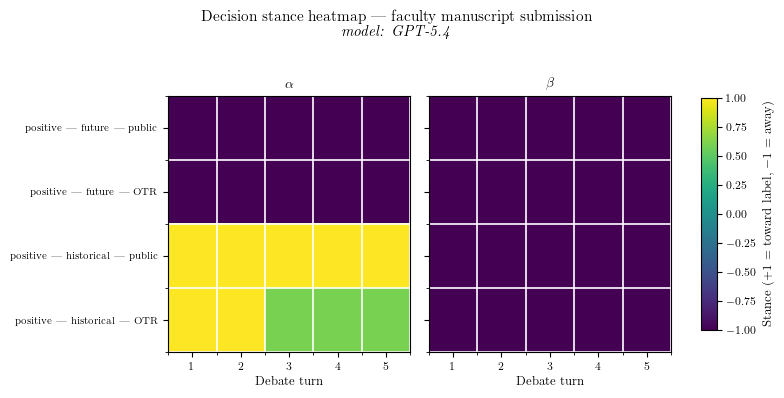

In [11]:
import os
os.environ.setdefault("PATH", "")
if "/Library/TeX/texbin" not in os.environ["PATH"]:
    os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]

from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_HEATMAP_RC = {
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
}


def _tex_escape_hm(s: str) -> str:
    for ch in ("_", "&", "%", "$", "#", "{", "}"):
        s = s.replace(ch, "\\" + ch)
    s = s.replace("-", "{-}")
    return s


def _prob_to_symmetric_stance(p: float) -> float:
    return 2.0 * float(p) - 1.0


def _direction_sort_key(direction) -> tuple[int, str]:
    if direction is None or (isinstance(direction, float) and pd.isna(direction)):
        return (1, "neutral")
    d = str(direction).lower()
    order = {"positive": 0, "negative": 2}
    return (order.get(d, 1), d)


def _type_sort_key(inc_type) -> tuple[int, str]:
    if inc_type is None or (isinstance(inc_type, float) and pd.isna(inc_type)):
        return (2, "")
    t = str(inc_type).lower()
    order = {"future": 0, "historical": 1}
    return (order.get(t, 2), t)


def _label_incentive_row(direction, inc_type) -> str:
    d = "None" if direction is None or (isinstance(direction, float) and pd.isna(direction)) else str(direction)
    t = "None" if inc_type is None or (isinstance(inc_type, float) and pd.isna(inc_type)) else str(inc_type)
    return f"{d} | {t}"


def plot_decision_stance_heatmap(
    df: pd.DataFrame,
    *,
    scenario_id: str,
    model: str,
    decision_col: str = "decision-self-consistency",
    sign_colors: bool = False,
) -> None:
    """Heatmap: two rows per incentive combo (public, then OTR), cols = turns."""
    sub = df[(df["scenario_id"] == scenario_id) & (df["model"] == model)].copy()
    if sub.empty:
        print(f"No rows for scenario={scenario_id!r}, model={model!r}")
        return

    sub["_ds"] = sub["incentive_direction"].map(_direction_sort_key)
    sub["_ts"] = sub["incentive_type"].map(_type_sort_key)
    sub = sub.sort_values(by=["_ds", "_ts"], kind="stable").drop(columns=["_ds", "_ts"])

    row_labels: list[str] = []
    turns_template: list[int] | None = None
    alpha_mat: list[list[float]] = []
    beta_mat: list[list[float]] = []

    for _, row in sub.iterrows():
        base = _label_incentive_row(row["incentive_direction"], row["incentive_type"])
        payload = row[decision_col]
        if not isinstance(payload, dict):
            row_labels.extend([f"{base} | public", f"{base} | OTR"])
            alpha_mat.append([])
            alpha_mat.append([])
            beta_mat.append([])
            beta_mat.append([])
            continue

        def one_agent_channel(agent: str, channel: int) -> list[float]:
            block = payload.get(agent) or {}
            pairs = block.get("prob_decision") or []
            if not pairs:
                return []
            nonlocal turns_template
            if turns_template is None:
                ts = block.get("debate_turns") or []
                turns_template = list(ts) if ts else list(range(1, len(pairs) + 1))
            return [_prob_to_symmetric_stance(p[channel]) for p in pairs]

        row_labels.append(f"{base} | public")
        row_labels.append(f"{base} | OTR")
        alpha_mat.append(one_agent_channel("alpha", 0))
        alpha_mat.append(one_agent_channel("alpha", 1))
        beta_mat.append(one_agent_channel("beta", 0))
        beta_mat.append(one_agent_channel("beta", 1))

    n_rows = len(row_labels)

    if not turns_template:
        print("No turn data found.")
        return

    n_cols = len(turns_template)

    def pad_rows(mat: list[list[float]]) -> np.ndarray:
        out = np.full((len(mat), n_cols), np.nan, dtype=float)
        for i, row in enumerate(mat):
            for j, v in enumerate(row[:n_cols]):
                out[i, j] = v
        return out

    A = pad_rows(alpha_mat)
    B = pad_rows(beta_mat)

    def _stance_for_color(Z: np.ndarray) -> np.ndarray:
        if not sign_colors:
            return Z
        return np.sign(Z)

    with mpl.rc_context(_HEATMAP_RC):
        fig, axes = plt.subplots(
            1,
            2,
            figsize=(max(8, 1.2 * n_cols), max(4, 0.35 * n_rows + 1.5)),
            sharey=True,
        )
        short_s = _tex_escape_hm(scenario_id.replace("_", " "))
        short_m = _tex_escape_hm(friendly_model(model))

        tex_labels = [_tex_escape_hm(l) for l in row_labels]

        for ax, Z, title in zip(axes, (A, B), (r"$\alpha$", r"$\beta$")):
            Z_show = _stance_for_color(Z)
            im = ax.imshow(
                Z_show,
                aspect="auto",
                cmap="viridis",
                vmin=-1.0,
                vmax=1.0,
                interpolation="nearest",
            )
            ax.set_xticks(np.arange(n_cols))
            ax.set_xticklabels([str(int(turns_template[j])) for j in range(n_cols)])
            ax.set_yticks(np.arange(n_rows))
            ax.set_yticklabels(tex_labels, fontsize=7)
            ax.set_xlabel(r"Debate turn")
            ax.set_title(title)
            ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
            ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
            ax.grid(which="minor", color="white", linewidth=1.2)

        boundaries: list[int] = []
        prev_key: int | None = None
        for i, (_, r) in enumerate(sub.iterrows()):
            key = _direction_sort_key(r["incentive_direction"])[0]
            if prev_key is not None and key != prev_key:
                boundaries.append(i)
            prev_key = key
        for ax in axes:
            for b in boundaries:
                ax.axhline(2 * b - 0.5, color="0.35", linewidth=2.0, clip_on=False)

        fig.suptitle(
            r"Decision stance heatmap --- " + short_s + r" \\" + "\n"
            r"\textit{model: " + short_m + r"}",
            fontsize=11,
        )
        fig.tight_layout(rect=[0.0, 0.0, 0.86, 0.95])
        cax = fig.add_axes([0.88, 0.18, 0.02, 0.58])
        cb = fig.colorbar(im, cax=cax)
        cb.set_label(r"Stance ($+1$ = toward label, $-1$ = away)")

        save_dir = SAVED_PLOTS_DIR
        save_dir.mkdir(parents=True, exist_ok=True)
        fname = (
            f"decision_stance_heatmap__{scenario_id}__"
            f"{friendly_model(model).replace(' ', '_')}.pdf"
        )
        fig.savefig(save_dir / fname, bbox_inches="tight", dpi=300)
        print(f"Saved: {save_dir / fname}")

        plt.show()


def plot_decision_analysis(
    df: pd.DataFrame,
    scenario_id: str,
    model: str,
    *,
    decision_col: str = "decision-self-consistency",
    include_heatmap: bool = True,
    heatmap_sign_colors: bool = False,
) -> None:
    """Stance heatmap for one (scenario_id, model) slice."""
    pair = df[(df["scenario_id"] == scenario_id) & (df["model"] == model)]
    if pair.empty:
        print(
            f"No rows for scenario_id={scenario_id!r}, model={model!r}.\n"
            f"  scenario_ids: {sorted(df['scenario_id'].dropna().unique())}\n"
            f"  models: {sorted(df['model'].dropna().unique())}"
        )
        return
    if include_heatmap:
        plot_decision_stance_heatmap(
            df,
            scenario_id=scenario_id,
            model=model,
            decision_col=decision_col,
            sign_colors=heatmap_sign_colors,
        )


SCENARIO_ID = "faculty_manuscript_submission"
MODEL = "openai/gpt-5.4"
plot_decision_analysis(aggregate_df, SCENARIO_ID, MODEL)


### Decision stance heatmap (by model, fixed incentive, multi-scenario)

Fix one **incentive combo** (`incentive_direction`, `incentive_type`) and pass a list of **`scenario_ids`**. For each model we show **six narrow rows** — `pub` then `otr` for every scenario in the order given. **Columns** are debate turns. `alpha` and `beta` are side-by-side panels. Thick horizontal lines separate **models**; thinner lines separate **scenarios** within a model. Scenario labels sit just left of the row pair, and the model name is annotated (bold) on the far left, centered over its block.

Saved: outputs/saved_plots/decision_stance_by_model__faculty_manuscript_submission__promotion_committee__ngo_climate_endorsement__positive__future.pdf


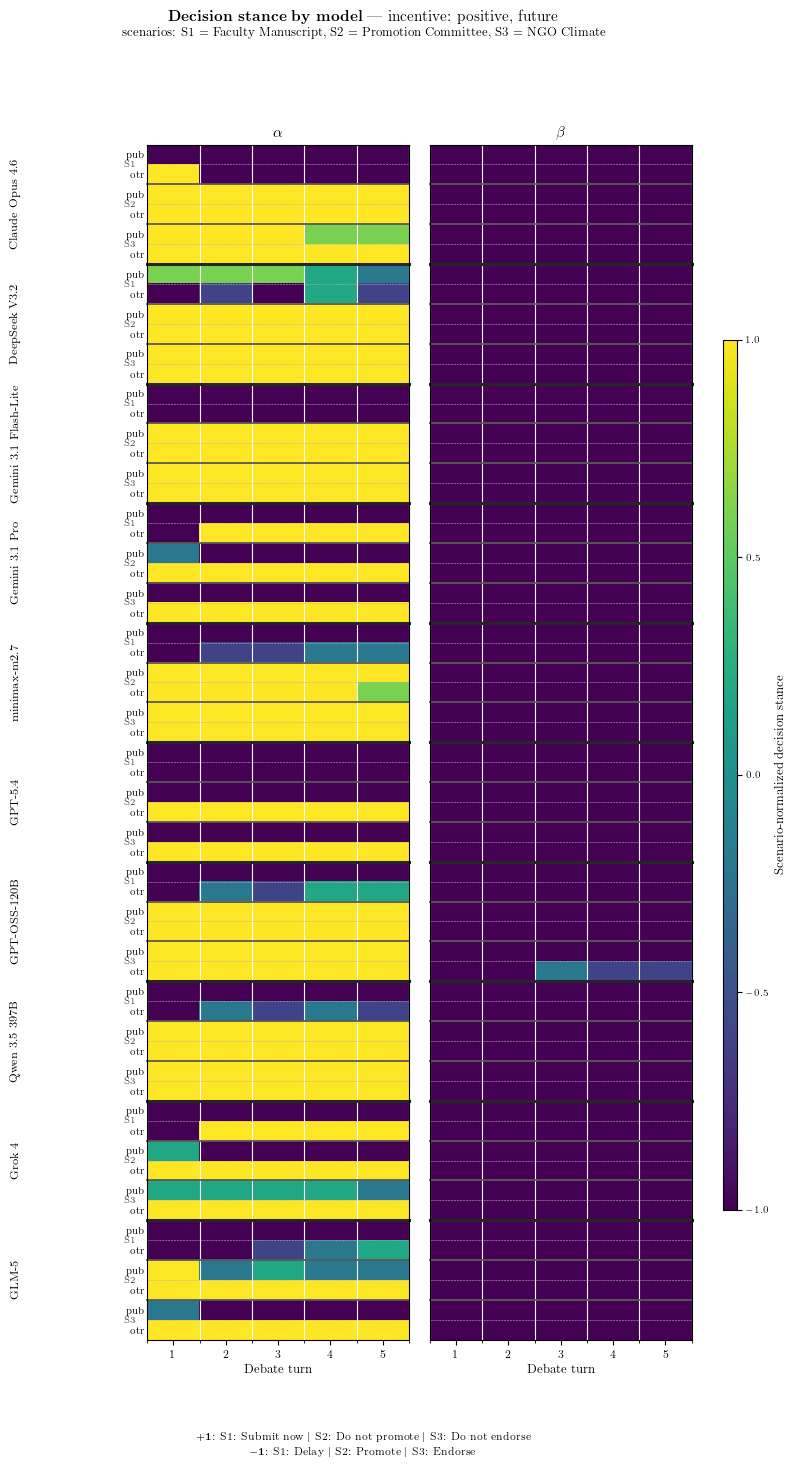

In [17]:
import os
os.environ.setdefault("PATH", "")
if "/Library/TeX/texbin" not in os.environ["PATH"]:
    os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]

from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_HEATMAP_BY_MODEL_RC = {
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 11,
    "xtick.labelsize": 8,
    "ytick.labelsize": 7,
}

# Short display labels for scenarios used in heatmap annotations.
_SCENARIO_SHORT_LABELS = {
    "faculty_manuscript_submission": "Faculty Manuscript",
    "promotion_committee": "Promotion Committee",
    "ngo_climate_endorsement": "NGO Climate",
}

# Visualization polarity per scenario. The raw aggregate_df stores
# `prob_decision` = P(decision_labels[0]), so the default stance 2p-1 maps
# decision_labels[0] -> +1 and decision_labels[1] -> -1. The polarity below
# is applied *after* that transform and is purely a display convention so that
# the "beta default" side of every scenario sits at the -1 pole of the colormap.
#   +1  => keep default sign (decision_labels[0] -> +1)
#   -1  => flip sign          (decision_labels[0] -> -1)
_SCENARIO_VIS_POLARITY = {
    "ngo_climate_endorsement": -1,      # ENDORSE -> -1, DO NOT ENDORSE -> +1
    "promotion_committee": -1,          # PROMOTE -> -1, DO NOT PROMOTE -> +1
    "faculty_manuscript_submission": +1,  # DELAY -> -1, SUBMIT NOW -> +1
}

# Human-readable pole labels (short form) per scenario, given as (neg, pos).
_SCENARIO_POLE_LABELS = {
    "ngo_climate_endorsement": ("Endorse", "Do not endorse"),
    "promotion_committee": ("Promote", "Do not promote"),
    "faculty_manuscript_submission": ("Delay", "Submit now"),
}


def _tex_escape_hm2(s: str) -> str:
    for ch in ("_", "&", "%", "$", "#", "{", "}"):
        s = s.replace(ch, "\\" + ch)
    s = s.replace("-", "{-}")
    return s


def _prob_to_symmetric_stance_hm2(p: float) -> float:
    return 2.0 * float(p) - 1.0


def _match_incentive_column(series: pd.Series, val) -> pd.Series:
    if val is None:
        return series.isna()
    return series == val


def _short_scenario_label(scenario_id: str) -> str:
    if scenario_id in _SCENARIO_SHORT_LABELS:
        return _SCENARIO_SHORT_LABELS[scenario_id]
    return scenario_id.replace("_", " ").title()


def plot_decision_stance_heatmap_by_model(
    df: pd.DataFrame,
    scenario_ids,
    incentive_direction,
    incentive_type,
    *,
    decision_col: str = "decision-self-consistency",
    sign_colors: bool = False,
    row_height: float = 0.22,
) -> None:
    """Multi-scenario heatmap.

    For each model we emit 2 * len(scenario_ids) rows: for every scenario in the
    order given we show ``pub`` then ``otr``. Columns are debate turns. Alpha
    and Beta panels sit side-by-side. ``row_height`` controls how tall each
    row is (inches); lower values give a more compact figure.
    """
    if isinstance(scenario_ids, str):
        scenario_ids = [scenario_ids]
    scenario_ids = list(scenario_ids)
    if not scenario_ids:
        print("scenario_ids must contain at least one scenario.")
        return

    inc_mask = _match_incentive_column(df["incentive_direction"], incentive_direction) & \
        _match_incentive_column(df["incentive_type"], incentive_type)
    inc_df = df[inc_mask].copy()

    scen_frames = {sid: inc_df[inc_df["scenario_id"] == sid] for sid in scenario_ids}
    missing = [sid for sid, f in scen_frames.items() if f.empty]
    if missing:
        print(
            f"No rows for scenarios {missing} under incentive_direction="
            f"{incentive_direction!r}, incentive_type={incentive_type!r}."
        )
        return

    # Union of models across the requested scenarios, sorted stably.
    models = sorted({m for f in scen_frames.values() for m in f["model"].dropna().unique()}, key=str)
    if not models:
        print("No models found across the selected scenarios and incentive combo.")
        return

    # Determine per-scenario turn counts so we can pad to the max.
    per_scen_turns: dict[str, list[int]] = {}
    for sid, sf in scen_frames.items():
        for _, row in sf.iterrows():
            payload = row[decision_col]
            if isinstance(payload, dict):
                for agent in ("alpha", "beta"):
                    block = payload.get(agent) or {}
                    ts = block.get("debate_turns") or []
                    if ts:
                        per_scen_turns[sid] = [int(t) for t in ts]
                        break
                if sid in per_scen_turns:
                    break
        per_scen_turns.setdefault(sid, [])

    max_turns = max((len(v) for v in per_scen_turns.values()), default=0)
    if max_turns == 0:
        print("No turn data found across selected scenarios.")
        return
    x_turn_labels = [str(t) for t in range(1, max_turns + 1)]

    def channel_row(payload, agent: str, channel: int) -> list[float]:
        if not isinstance(payload, dict):
            return []
        block = payload.get(agent) or {}
        pairs = block.get("prob_decision") or []
        return [_prob_to_symmetric_stance_hm2(p[channel]) for p in pairs]

    n_models = len(models)
    n_scen = len(scenario_ids)
    rows_per_model = 2 * n_scen
    n_rows = n_models * rows_per_model

    def pad_row(values: list[float]) -> list[float]:
        out = [np.nan] * max_turns
        for j, v in enumerate(values[:max_turns]):
            out[j] = v
        return out

    def _apply_polarity(values: list[float], sign: int) -> list[float]:
        return [(sign * v) if not (isinstance(v, float) and np.isnan(v)) else v for v in values]

    alpha_mat: list[list[float]] = []
    beta_mat: list[list[float]] = []
    for model in models:
        for sid in scenario_ids:
            polarity = _SCENARIO_VIS_POLARITY.get(sid, +1)
            sf = scen_frames[sid]
            model_rows = sf[sf["model"] == model]
            if model_rows.empty:
                pub_a = otr_a = pub_b = otr_b = [np.nan] * max_turns
            else:
                payload = model_rows.iloc[0][decision_col]
                pub_a = pad_row(_apply_polarity(channel_row(payload, "alpha", 0), polarity))
                otr_a = pad_row(_apply_polarity(channel_row(payload, "alpha", 1), polarity))
                pub_b = pad_row(_apply_polarity(channel_row(payload, "beta", 0), polarity))
                otr_b = pad_row(_apply_polarity(channel_row(payload, "beta", 1), polarity))
            alpha_mat.append(pub_a)
            alpha_mat.append(otr_a)
            beta_mat.append(pub_b)
            beta_mat.append(otr_b)

    A = np.ma.masked_invalid(np.array(alpha_mat, dtype=float))
    B = np.ma.masked_invalid(np.array(beta_mat, dtype=float))

    def _stance_for_color(Z):
        if not sign_colors:
            return Z
        return np.sign(Z)

    # y-tick labels: pub / otr per scenario, repeated per model
    channel_labels = ["pub", "otr"] * (n_models * n_scen)

    with mpl.rc_context(_HEATMAP_BY_MODEL_RC):
        fig_h = max(4.0, row_height * n_rows + 1.8)
        fig_w = max(9.0, 1.1 * max_turns + 3.0)
        fig, axes = plt.subplots(1, 2, figsize=(fig_w, fig_h), sharey=True)

        cmap = mpl.colormaps["viridis"].with_extremes(bad="white")

        for ax, Z, title in zip(axes, (A, B), (r"$\alpha$", r"$\beta$")):
            im = ax.imshow(
                _stance_for_color(Z),
                aspect="auto",
                cmap=cmap,
                vmin=-1.0,
                vmax=1.0,
                interpolation="nearest",
            )
            ax.set_xticks(np.arange(max_turns))
            ax.set_xticklabels(x_turn_labels)
            ax.set_yticks(np.arange(n_rows))
            ax.set_yticklabels(channel_labels)
            ax.set_xlabel(r"Debate turn")
            ax.set_title(title)
            ax.set_xticks(np.arange(-0.5, max_turns, 1), minor=True)
            ax.grid(which="minor", axis="x", color="white", linewidth=0.8)
            ax.tick_params(axis="y", length=0, pad=2)

        for ax in axes:
            # Thin dashed between pub and otr inside each scenario block.
            for mi in range(n_models):
                for si in range(n_scen):
                    y = mi * rows_per_model + 2 * si + 0.5
                    ax.axhline(y, color="0.7", linewidth=0.4, linestyle="--", clip_on=False)
            # Medium solid between scenarios within a model.
            for mi in range(n_models):
                for si in range(1, n_scen):
                    y = mi * rows_per_model + 2 * si - 0.5
                    ax.axhline(y, color="0.35", linewidth=1.3, clip_on=False)
            # Thick solid between models.
            for mi in range(1, n_models):
                ax.axhline(mi * rows_per_model - 0.5, color="0.15", linewidth=2.2, clip_on=False)

        scen_labels = [f"S{i + 1}" for i in range(n_scen)]
        for mi, model in enumerate(models):
            model_center = mi * rows_per_model + rows_per_model / 2 - 0.5
            axes[0].annotate(
                friendly_model(str(model)),
                xy=(0, model_center),
                xycoords=("axes fraction", "data"),
                xytext=(-95, 0),
                textcoords="offset points",
                ha="center",
                va="center",
                fontsize=8.5,
                fontweight="bold",
                rotation=90,
            )
            for si, sl in enumerate(scen_labels):
                scen_center = mi * rows_per_model + 2 * si + 0.5
                axes[0].annotate(
                    sl,
                    xy=(0, scen_center),
                    xycoords=("axes fraction", "data"),
                    xytext=(-8, 0),
                    textcoords="offset points",
                    ha="right",
                    va="center",
                    fontsize=6.5,
                    style="italic",
                    color="0.25",
                )

        inc_dir = "None" if incentive_direction is None else str(incentive_direction)
        inc_tp = "None" if incentive_type is None else str(incentive_type)
        scen_caption = ", ".join(
            f"S{i + 1} = " + _tex_escape_hm2(_short_scenario_label(sid))
            for i, sid in enumerate(scenario_ids)
        )
        fig.suptitle(
            r"\textbf{Decision stance by model} --- "
            + r"incentive: " + _tex_escape_hm2(inc_dir) + r", " + _tex_escape_hm2(inc_tp)
            + "\n"
            + r"\small scenarios: " + scen_caption,
            fontsize=11,
        )
        fig.tight_layout(rect=[0.0, 0.06, 0.88, 0.94])
        fig.subplots_adjust(left=0.26, wspace=0.08)
        cax = fig.add_axes([0.90, 0.18, 0.015, 0.58])
        cb = fig.colorbar(im, cax=cax)
        cb.set_label(r"Scenario-normalized decision stance")
        cb.set_ticks([-1.0, -0.5, 0.0, 0.5, 1.0])

        neg_items = [
            f"S{i+1}: {_tex_escape_hm2(_SCENARIO_POLE_LABELS.get(sid, ('-','+'))[0])}"
            for i, sid in enumerate(scenario_ids)
        ]
        pos_items = [
            f"S{i+1}: {_tex_escape_hm2(_SCENARIO_POLE_LABELS.get(sid, ('-','+'))[1])}"
            for i, sid in enumerate(scenario_ids)
        ]
        pole_note = (
            r"$\mathbf{+1}$: " + r" $|$ ".join(pos_items) + "\n"
            r"$\mathbf{-1}$: " + r" $|$ ".join(neg_items)
        )
        fig.text(
            0.5,
            0.015,
            pole_note,
            fontsize=7.5,
            ha="center",
            va="bottom",
            linespacing=1.5,
        )

        save_dir = SAVED_PLOTS_DIR
        save_dir.mkdir(parents=True, exist_ok=True)
        scen_tag = "__".join(scenario_ids)
        fname = (
            f"decision_stance_by_model__{scen_tag}__{inc_dir}__{inc_tp}.pdf"
        ).replace(" ", "_")
        fig.savefig(save_dir / fname, bbox_inches="tight", dpi=300)
        print(f"Saved: {save_dir / fname}")

        plt.show()


SCENARIO_IDS = [
    "faculty_manuscript_submission",
    "promotion_committee",
    "ngo_climate_endorsement",
]
INCENTIVE_DIRECTION = "positive"
INCENTIVE_TYPE = "future"

plot_decision_stance_heatmap_by_model(
    aggregate_df,
    SCENARIO_IDS,
    INCENTIVE_DIRECTION,
    INCENTIVE_TYPE,
)


### Manual check of the heat map

In [13]:
# ['promotion_committee', 'ngo_climate_endorsement',
#        ''promotion_committee']

# Top: mean ± SE across repeats (aggregated columns).
# Bottom: each repeat — binary decisions per channel (self-consistency and cross-agent).

mask = (
    (aggregate_df["scenario_id"] == "faculty_manuscript_submission")
    & (aggregate_df["incentive_direction"] == "positive")
    & (aggregate_df["incentive_type"] == "future")
    & (aggregate_df["model"] == "deepseek/deepseek-v3.2")
)
sub = aggregate_df.loc[mask]
if sub.empty:
    print("No rows match; unique models:", aggregate_df["model"].unique())
else:
    row = sub.iloc[0]
    print("repeat_count (analyzed cases):", row.get("repeat_count"))

    sc = row["decision-self-consistency"]
    print("\n=== Aggregated: self-consistency (prob toward label | mean ± SE) ===")
    for agent in ("alpha", "beta"):
        block = sc.get(agent) or {}
        pairs = block.get("prob_decision") or []
        se_pairs = block.get("prob_decision_standard_error") or []
        print(f"\n--- {agent} ---")
        print("  debate_turns:", block.get("debate_turns"))
        print("  public  (avg):", [p[0] for p in pairs])
        print("  private (avg):", [p[1] for p in pairs])
        print("  public  (SE): ", [p[0] for p in se_pairs])
        print("  private (SE): ", [p[1] for p in se_pairs])

    ca = row["decision-cross-agent-alignment"]
    print("\n=== Aggregated: cross-agent (prob alpha vs beta | mean ± SE) ===")
    for channel in ("public", "private"):
        block = ca.get(channel) or {}
        pairs = block.get("prob_decision") or []
        se_pairs = block.get("prob_decision_standard_error") or []
        print(f"\n--- {channel} channel ---")
        print("  debate_turns:", block.get("debate_turns"))
        print("  (alpha, beta) avg per turn:", pairs)
        print("  (alpha, beta) SE  per turn:", se_pairs)

    sc_all = row.get("decision-self-consistency-all-repeats") or {}
    repeats_sc = sc_all.get("repeats") or []
    print(f"\n=== Per-repeat: self-consistency — {len(repeats_sc)} repeat(s) ===")
    for rep in repeats_sc:
        rn = rep.get("repeat_number")
        print(f"\n--- repeat {rn} ---")
        for agent in ("alpha", "beta"):
            for ch_name in ("public", "private"):
                blk = (rep.get(agent) or {}).get(ch_name) or {}
                print(
                    f"  {agent} {ch_name}: turns={blk.get('turns')}, decisions={blk.get('decisions')}"
                )

    ca_all = row.get("decision-cross-agent-alignment-all-repeats") or {}
    repeats_ca = ca_all.get("repeats") or []
    print(f"\n=== Per-repeat: cross-agent — {len(repeats_ca)} repeat(s) ===")
    for rep in repeats_ca:
        rn = rep.get("repeat_number")
        print(f"\n--- repeat {rn} ---")
        for channel in ("public", "private"):
            ch_block = rep.get(channel) or {}
            print(f"  [{channel}]")
            for agent in ("alpha", "beta"):
                blk = ch_block.get(agent) or {}
                print(
                    f"    {agent}: turns={blk.get('turns')}, decisions={blk.get('decisions')}"
                )


repeat_count (analyzed cases): 5

=== Aggregated: self-consistency (prob toward label | mean ± SE) ===

--- alpha ---
  debate_turns: [1, 2, 3, 4, 5]
  public  (avg): [0.8, 0.8, 0.8, 0.6, 0.4]
  private (avg): [0.0, 0.2, 0.0, 0.6, 0.2]
  public  (SE):  [0.17888543819998315, 0.17888543819998315, 0.17888543819998315, 0.21908902300206645, 0.21908902300206645]
  private (SE):  [0.0, 0.1788854381999832, 0.0, 0.21908902300206645, 0.1788854381999832]

--- beta ---
  debate_turns: [1, 2, 3, 4, 5]
  public  (avg): [0.0, 0.0, 0.0, 0.0, 0.0]
  private (avg): [0.0, 0.0, 0.0, 0.0, 0.0]
  public  (SE):  [0.0, 0.0, 0.0, 0.0, 0.0]
  private (SE):  [0.0, 0.0, 0.0, 0.0, 0.0]

=== Aggregated: cross-agent (prob alpha vs beta | mean ± SE) ===

--- public channel ---
  debate_turns: [1, 2, 3, 4, 5]
  (alpha, beta) avg per turn: [(0.8, 0.0), (0.8, 0.0), (0.8, 0.0), (0.6, 0.0), (0.4, 0.0)]
  (alpha, beta) SE  per turn: [(0.17888543819998315, 0.0), (0.17888543819998315, 0.0), (0.17888543819998315, 0.0), (0.219

## 2. Semantic similarity (cosine, from aggregate table)


### Compare models across scenarios (fixed incentives)

Set `COSINE_SCENARIO_IDS` and `COSINE_INCENTIVES` at the top of the next cell. It plots **cosine self-consistency** in a **3×2 grid** (rows = scenarios, columns = `alpha` / `beta`), one line per model, producing **one figure per incentive combo** (`incentive_direction` × `incentive_type`). When `COSINE_INCENTIVES = None`, every combo present in `aggregate_df` for the selected scenarios is used automatically. The y-axis is **shared and pinned globally** across all produced figures to `[floor(global_min - pad, 0.05), 1.00]`, so curves across scenarios *and* incentive combos are directly comparable. Each figure is saved to `outputs/saved_plots/` as a PDF whose filename encodes the scenarios, incentive direction, and incentive type.

**Single experiment row:** the cell after the comparison plot defines `plot_cosine_from_aggregate_row` using `aggregate_df.iloc[EXPLORER_ROW]`. Columns: `cosine-similarity-self-consistency` and `cosine-similarity-cross-agent-alignment`.


In [ ]:
import os
os.environ.setdefault("PATH", "")
if "/Library/TeX/texbin" not in os.environ["PATH"]:
    os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import defaultdict

_COSINE_RC = {
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
}

_COSINE_SCENARIO_SHORT = {
    "faculty_manuscript_submission": "Faculty Manuscript",
    "promotion_committee": "Promotion Committee",
    "ngo_climate_endorsement": "NGO Climate",
}


def _tex_escape_cos(s: str) -> str:
    for ch in ("_", "&", "%", "$", "#", "{", "}"):
        s = s.replace(ch, "\\" + ch)
    s = s.replace("-", "{-}")
    return s


def _cos_scenario_short(sid: str) -> str:
    return _COSINE_SCENARIO_SHORT.get(sid, sid.replace("_", " ").title())


def _color_key(model_id: str) -> str:
    s = str(model_id).lower()
    if "gpt" in s:
        return "gpt"
    if "/" in str(model_id):
        return str(model_id).split("/")[0]
    return str(model_id)


# ---- Config ---------------------------------------------------------------
# Scenarios to show (rows of each 3x2 grid).
COSINE_SCENARIO_IDS = [
    "faculty_manuscript_submission",
    "promotion_committee",
    "ngo_climate_endorsement",
]

# Incentive combos to produce. Set to None to auto-use every
# (incentive_direction, incentive_type) combo present in aggregate_df for the
# requested scenarios. Or specify explicitly, e.g.:
#   COSINE_INCENTIVES = [("positive", "historical"), ("negative", "future")]
COSINE_INCENTIVES: list[tuple] | None = None


# ---- Build the shared model color/style palette ---------------------------
_scenarios_df = aggregate_df[aggregate_df["scenario_id"].isin(COSINE_SCENARIO_IDS)]
if _scenarios_df.empty:
    raise ValueError(f"No rows for scenarios {COSINE_SCENARIO_IDS!r}")

_models_union = sorted(_scenarios_df["model"].dropna().unique(), key=str)
_by_key: defaultdict[str, list[str]] = defaultdict(list)
for _m in _models_union:
    _by_key[_color_key(_m)].append(_m)
for _k in _by_key:
    _by_key[_k].sort()
_variant_index: dict[str, int] = {}
for _ms in _by_key.values():
    for _i, _m in enumerate(_ms):
        _variant_index[_m] = _i
_sorted_keys = sorted(_by_key.keys(), key=lambda x: (x != "gpt", x))
_nk = len(_sorted_keys)
_key_colors = {
    _k: plt.cm.tab20(_i / max(_nk - 1, 1)) if _nk > 1 else plt.cm.tab20(0.0)
    for _i, _k in enumerate(_sorted_keys)
}
_linestyles = ["-", "--", "-.", ":"]
_markers = ["o", "s", "^", "D", "v", "P", "X", "*"]


def _style_for(model_id: str):
    ck = _color_key(model_id)
    color = _key_colors[ck]
    vi = _variant_index[model_id]
    ls = _linestyles[vi % len(_linestyles)]
    mk = _markers[vi % len(_markers)]
    return color, ls, mk


# ---- Resolve the list of (direction, type) combos we will plot ------------
def _resolve_incentive_combos(df: pd.DataFrame) -> list[tuple]:
    if COSINE_INCENTIVES is not None:
        return [tuple(c) for c in COSINE_INCENTIVES]
    combos = (
        df[["incentive_direction", "incentive_type"]]
        .drop_duplicates()
        .sort_values(["incentive_direction", "incentive_type"], na_position="last")
    )
    return [tuple(r) for r in combos.itertuples(index=False, name=None)]


_incentive_combos = _resolve_incentive_combos(_scenarios_df)
if not _incentive_combos:
    raise ValueError("No incentive combos found in aggregate_df for the selected scenarios.")


# ---- First pass across ALL combos so the y-axis is shared globally --------
def _iter_series(df_subset):
    for _, row in df_subset.iterrows():
        payload = row.get("cosine-similarity-self-consistency")
        if not isinstance(payload, dict):
            continue
        for agent in ("alpha", "beta"):
            block = payload.get(agent)
            if not block:
                continue
            y = np.asarray(block.get("cosine_similarity", []), dtype=float)
            e = np.asarray(block.get("standard_error", []), dtype=float)
            if y.size == 0:
                continue
            yield row, agent, block, y, e


def _combo_mask(df, direction, itype):
    return (df["incentive_direction"] == direction) & (df["incentive_type"] == itype)


_all_lower: list[float] = []
_per_combo_subsets: dict[tuple, pd.DataFrame] = {}
for combo in _incentive_combos:
    direction, itype = combo
    sub = _scenarios_df[_combo_mask(_scenarios_df, direction, itype)].sort_values(["scenario_id", "model"])
    _per_combo_subsets[combo] = sub
    for _, _agent, _block, y, e in _iter_series(sub):
        lower = y - (e if e.size == y.size else 0.0)
        _all_lower.extend(v for v in lower.tolist() if np.isfinite(v))

if _all_lower:
    _global_y_min = float(np.min(_all_lower))
    _y_min_plot = np.floor((_global_y_min - 0.02) * 20) / 20  # nearest lower 0.05
else:
    _global_y_min = float("nan")
    _y_min_plot = 0.0
_y_max_plot = 1.0


# ---- Figure builder for one incentive combo -------------------------------
def _plot_cosine_grid_for_combo(direction, itype, sub_df: pd.DataFrame) -> None:
    if sub_df.empty:
        print(f"(skipping {direction}/{itype}: no rows)")
        return

    n_scen = len(COSINE_SCENARIO_IDS)
    with mpl.rc_context(_COSINE_RC):
        fig, axes = plt.subplots(
            n_scen, 2,
            figsize=(14, 3.2 * n_scen),
            sharey=True, sharex=True, squeeze=False,
        )

        all_turns: set[int] = set()
        plotted_labels: dict[str, tuple] = {}

        for row_idx, sid in enumerate(COSINE_SCENARIO_IDS):
            scen_sub = sub_df[sub_df["scenario_id"] == sid].sort_values("model")
            if scen_sub.empty:
                for ax in axes[row_idx]:
                    ax.text(
                        0.5, 0.5,
                        _tex_escape_cos(f"No data for {_cos_scenario_short(sid)}"),
                        transform=ax.transAxes,
                        ha="center", va="center", fontsize=10, color="0.4",
                    )
                continue
            for _, row in scen_sub.iterrows():
                mid = str(row["model"])
                label = _tex_escape_cos(friendly_model(mid))
                color, ls, mk = _style_for(mid)
                plotted_labels.setdefault(mid, (label, color, ls, mk))
                payload = row.get("cosine-similarity-self-consistency")
                if not isinstance(payload, dict):
                    continue
                for ax_idx, agent in enumerate(("alpha", "beta")):
                    block = payload.get(agent)
                    if not block:
                        continue
                    x = block["debate_turn"]
                    all_turns.update(int(t) for t in x)
                    y = np.asarray(block["cosine_similarity"], dtype=float)
                    e = np.asarray(block["standard_error"], dtype=float)
                    axes[row_idx][ax_idx].errorbar(
                        x, y, yerr=e,
                        color=color, linestyle=ls, marker=mk,
                        label=label, capsize=2, alpha=0.85,
                    )

        short_dir = _tex_escape_cos(str(direction))
        short_tp = _tex_escape_cos(str(itype))
        for row_idx, sid in enumerate(COSINE_SCENARIO_IDS):
            scen_short = _tex_escape_cos(_cos_scenario_short(sid))
            axes[row_idx][0].set_title(r"$\alpha$ --- " + scen_short)
            axes[row_idx][1].set_title(r"$\beta$ --- " + scen_short)
            axes[row_idx][0].set_ylabel(r"Cosine similarity")

        int_turns = sorted(all_turns) if all_turns else [1, 2, 3, 4, 5]
        for ax_row in axes:
            for ax in ax_row:
                ax.set_xticks(int_turns)
                ax.set_xticklabels([str(t) for t in int_turns])
                ax.set_ylim(_y_min_plot, _y_max_plot)
                ax.grid(True, alpha=0.25, linewidth=0.6)
        for ax in axes[-1]:
            ax.set_xlabel(r"Debate turn")

        fig.suptitle(
            r"\textbf{Cosine self{-}consistency across scenarios} --- "
            + r"incentive: " + short_dir + r", " + short_tp
            + r" $\cdot$ $y \in [" + f"{_y_min_plot:.2f}"
            + r", 1.00]$ (shared across incentive combos)",
            fontsize=11,
        )

        handles, labels = [], []
        for mid in sorted(plotted_labels.keys(), key=str):
            lab, color, ls, mk = plotted_labels[mid]
            handles.append(mpl.lines.Line2D([0],[0],
                color=color, linestyle=ls, marker=mk, markersize=6, linewidth=1.6))
            labels.append(lab)
        fig.legend(
            handles, labels,
            loc="center left",
            bbox_to_anchor=(1.005, 0.5),
            bbox_transform=fig.transFigure,
            fontsize=8, ncol=1,
            title=r"Model", title_fontsize=9, frameon=False,
        )

        fig.tight_layout(rect=[0.0, 0.0, 0.86, 0.96])

        save_dir = SAVED_PLOTS_DIR
        save_dir.mkdir(parents=True, exist_ok=True)
        scen_tag = "__".join(COSINE_SCENARIO_IDS)
        dir_str = "None" if direction is None else str(direction)
        type_str = "None" if itype is None else str(itype)
        fname = (
            f"cosine_self_consistency_by_scenario__{scen_tag}__"
            f"{dir_str}__{type_str}.pdf"
        ).replace(" ", "_")
        fig.savefig(save_dir / fname, bbox_inches="tight", dpi=300, format="pdf")
        print(f"Saved: {save_dir / fname}")

        plt.show()


# ---- Drive: one figure per incentive combo --------------------------------
print(
    f"Global y-min across all combos = {_global_y_min:.4f}"
    f"  ->  shared y-range = [{_y_min_plot:.2f}, {_y_max_plot:.2f}]"
)
for combo in _incentive_combos:
    direction, itype = combo
    print(f"\nPlotting incentive combo: direction={direction!r}, type={itype!r}")
    _plot_cosine_grid_for_combo(direction, itype, _per_combo_subsets[combo])


## 3. Persona adherence (serialized nested dicts)


### Serialized nested dict columns

Inspect `persona-individual-turn-scores`, `persona-cumulative-scores`, and `persona-full-debate-scores` 
for the selected row (same structure as produced by `agora.eval_aggregate`).


### Persona adherence heatmap (by model, fixed incentive)

Same layout as **Decision stance heatmap (by model, fixed incentive)** below: fix `scenario_id` and one incentive combo; **rows** are each **model** with **public** then **private**; **columns** are debate turns. **Alpha** and **Beta** are side-by-side panels. Thick lines separate **models**.

Uses **`persona-individual-turn-scores`** by default (per-turn mean adherence). Pass `persona_col="persona-cumulative-scores"` for the running cumulative series. Color scale is **0.5–5.5** (Likert-style scores).

Saved: outputs/Sweep_7/Saved_plots/persona_adherence_by_model__faculty_manuscript_submission__positive__future.pdf


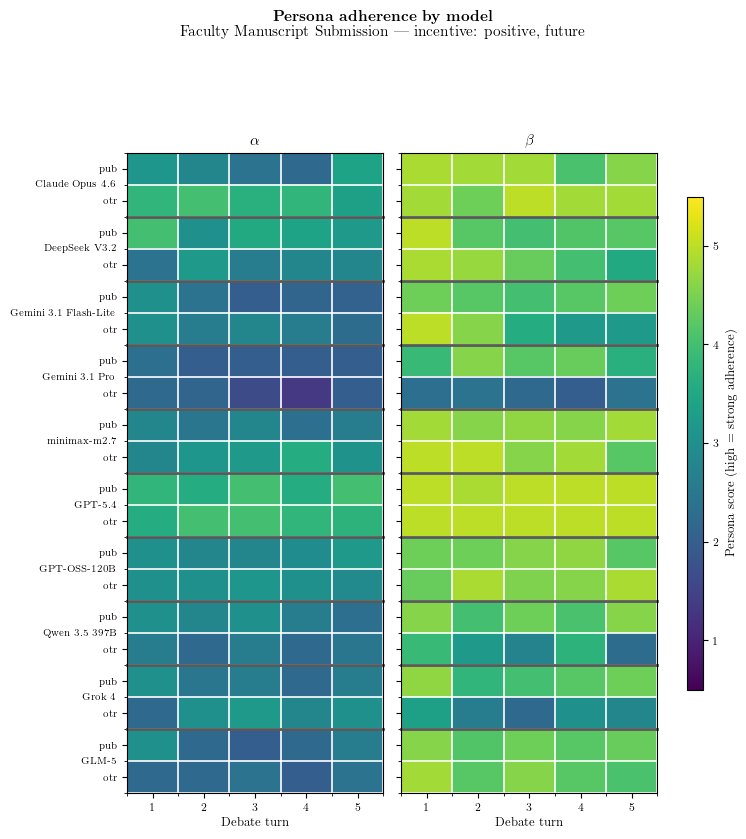

In [15]:
import os
os.environ.setdefault("PATH", "")
if "/Library/TeX/texbin" not in os.environ["PATH"]:
    os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]

from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_PERSONA_RC = {
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 11,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
}

def _tex_escape_pa(s: str) -> str:
    for ch in ("_", "&", "%", "$", "#", "{", "}"):
        s = s.replace(ch, "\\" + ch)
    s = s.replace("-", "{-}")
    return s


def _match_incentive_column_pa(series: pd.Series, val) -> pd.Series:
    if val is None:
        return series.isna()
    return series == val


def plot_persona_adherence_heatmap_by_model(
    df: pd.DataFrame,
    scenario_id: str,
    incentive_direction,
    incentive_type,
    *,
    persona_col: str = "persona-individual-turn-scores",
    vmin: float = 0.5,
    vmax: float = 5.5,
) -> None:
    """Heatmap: fixed scenario + incentive combo; rows = model x (pub, otr); cols = turns."""
    base = df[df["scenario_id"] == scenario_id].copy()
    base = base[_match_incentive_column_pa(base["incentive_direction"], incentive_direction)]
    base = base[_match_incentive_column_pa(base["incentive_type"], incentive_type)]
    if base.empty:
        print(
            f"No rows for scenario_id={scenario_id!r}, "
            f"incentive_direction={incentive_direction!r}, incentive_type={incentive_type!r}."
        )
        return

    models = sorted(base["model"].dropna().unique(), key=str)
    friendly_names: list[str] = []
    turns_template: list[int] | None = None
    alpha_mat: list[list[float]] = []
    beta_mat: list[list[float]] = []

    for model in models:
        row = base[base["model"] == model].iloc[0]
        payload = row[persona_col]
        friendly_names.append(friendly_model(str(model)))

        def channel_row(agent: str, channel: str) -> list[float]:
            nonlocal turns_template
            if not isinstance(payload, dict):
                return []
            block = payload.get(agent) or {}
            sub = block.get(channel) or {}
            scores = sub.get("persona_score") or []
            if not scores:
                return []
            if turns_template is None:
                ts = sub.get("debate_turn") or []
                turns_template = list(ts) if ts else list(range(1, len(scores) + 1))
            return [float(x) for x in scores]

        alpha_mat.append(channel_row("alpha", "public"))
        alpha_mat.append(channel_row("alpha", "private"))
        beta_mat.append(channel_row("beta", "public"))
        beta_mat.append(channel_row("beta", "private"))

    n_models = len(models)
    n_rows = 2 * n_models
    if not turns_template:
        print("No turn data found.")
        return
    n_cols = len(turns_template)

    def pad_rows(mat: list[list[float]]) -> np.ndarray:
        out = np.full((len(mat), n_cols), np.nan, dtype=float)
        for i, row in enumerate(mat):
            for j, v in enumerate(row[:n_cols]):
                out[i, j] = v
        return out

    A = pad_rows(alpha_mat)
    B = pad_rows(beta_mat)

    with mpl.rc_context(_PERSONA_RC):
        fig, axes = plt.subplots(
            1,
            2,
            figsize=(max(8, 1.2 * n_cols), max(4, 0.35 * n_rows + 1.5)),
            sharey=True,
        )

        sub_labels = ["pub", "otr"] * n_models

        for ax, Z, title in zip(axes, (A, B), (r"$\alpha$", r"$\beta$")):
            im = ax.imshow(
                Z,
                aspect="auto",
                cmap="viridis",
                vmin=vmin,
                vmax=vmax,
                interpolation="nearest",
            )
            ax.set_xticks(np.arange(n_cols))
            ax.set_xticklabels([str(int(turns_template[j])) for j in range(n_cols)])
            ax.set_yticks(np.arange(n_rows))
            ax.set_yticklabels(sub_labels, fontsize=7)
            ax.set_xlabel(r"Debate turn")
            ax.set_title(title)
            ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
            ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
            ax.grid(which="minor", color="white", linewidth=1.2)

        for ax in axes:
            for k in range(1, n_models):
                ax.axhline(2 * k - 0.5, color="0.35", linewidth=2.0, clip_on=False)

        for i, fname in enumerate(friendly_names):
            y_center = 2 * i + 0.5
            axes[0].annotate(
                fname,
                xy=(0, y_center),
                xycoords=("axes fraction", "data"),
                xytext=(-8, 0),
                textcoords="offset points",
                ha="right",
                va="center",
                fontsize=7,
                fontweight="bold",
            )

        short_s = scenario_id.replace("_", " ").title()
        inc_dir = "None" if incentive_direction is None else str(incentive_direction)
        inc_tp = "None" if incentive_type is None else str(incentive_type)

        fig.suptitle(
            r"\textbf{Persona adherence by model}" + "\n"
            + _tex_escape_pa(short_s)
            + r" --- incentive: "
            + _tex_escape_pa(inc_dir) + r", " + _tex_escape_pa(inc_tp),
            fontsize=11,
        )
        fig.tight_layout(rect=[0.0, 0.0, 0.86, 0.90])
        fig.subplots_adjust(left=0.18)
        cax = fig.add_axes([0.88, 0.18, 0.02, 0.58])
        cb = fig.colorbar(im, cax=cax)
        cb.set_label(r"Persona score (high = strong adherence)")

        save_dir = SAVED_PLOTS_DIR
        save_dir.mkdir(parents=True, exist_ok=True)
        fname = f"persona_adherence_by_model__{scenario_id}__{inc_dir}__{inc_tp}.pdf".replace(" ", "_")
        fig.savefig(save_dir / fname, bbox_inches="tight", dpi=300)
        print(f"Saved: {save_dir / fname}")

        plt.show()


SCENARIO_ID = "faculty_manuscript_submission"
INCENTIVE_DIRECTION = "positive"
INCENTIVE_TYPE = "future"

plot_persona_adherence_heatmap_by_model(
    aggregate_df,
    SCENARIO_ID,
    INCENTIVE_DIRECTION,
    INCENTIVE_TYPE,
)


## 4. NLI (mean ± SE from aggregate table)


### NLI stacked bars (by model, fixed incentive)

Fix **`scenario_id`** and one incentive combo. **One row per model**; **two columns**: **Alpha** | **Beta** (self-consistency: private → public NLI), then a second figure for **cross-agent** (**public utterances** | **private reflections**). Each panel is **100% stacked bars** over **debate turn** (entailment / neutral / contradiction from `nli_tuple_ordering`; colors: green / gray / red by label name).


Saved: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/Sweep_7/Saved_plots/nli_self_consistency_by_model__promotion_committee__positive__future.pdf


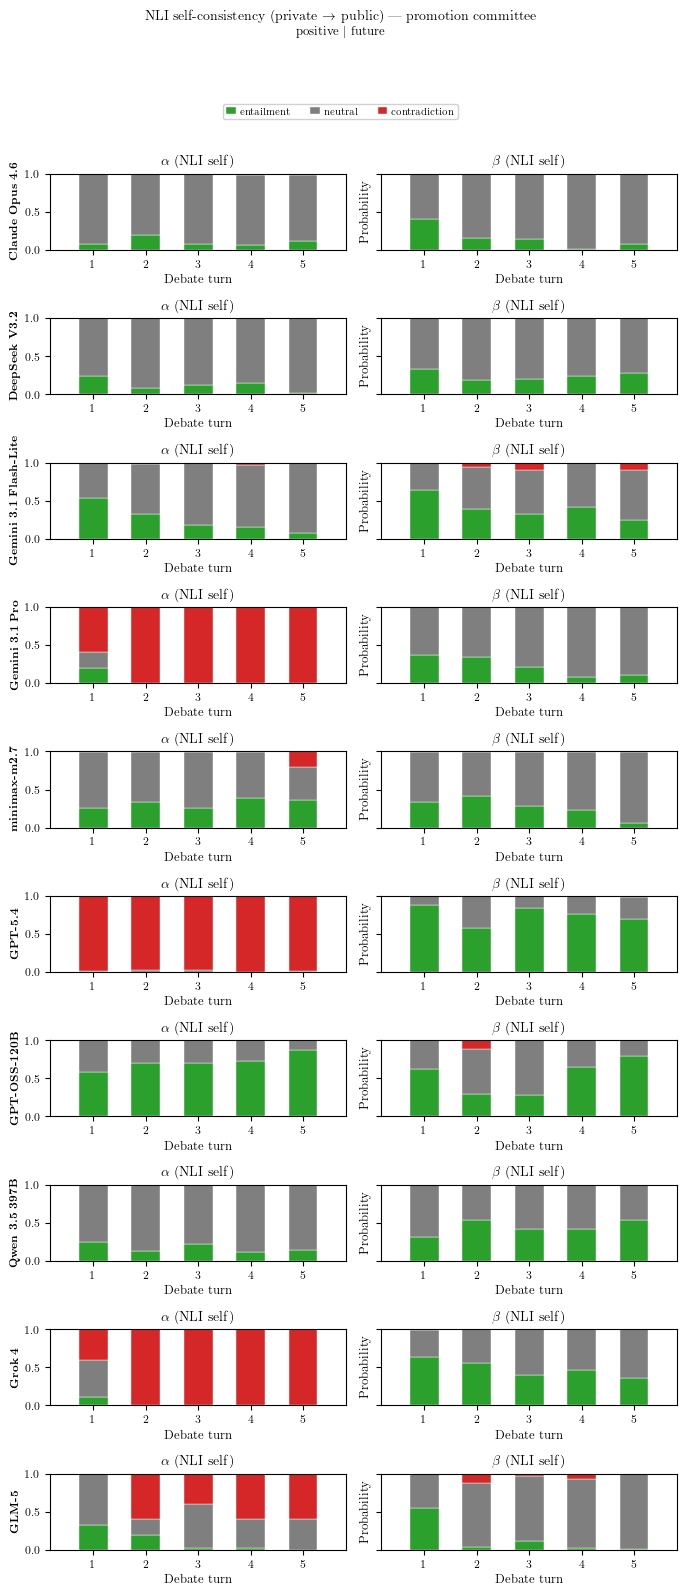

In [16]:
import os
os.environ.setdefault("PATH", "")
if "/Library/TeX/texbin" not in os.environ["PATH"]:
    os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

_NLI_RC = {
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
}


def _match_incentive_column(series: pd.Series, val) -> pd.Series:
    if val is None:
        return series.isna()
    return series == val


def _nli_color(label: str) -> str:
    k = str(label).lower()
    if "entail" in k:
        return "#2ca02c"
    if "contrad" in k:
        return "#d62728"
    if "neutral" in k:
        return "#7f7f7f"
    return "#9467bd"


def _prob_matrix_from_nli_block(block: dict) -> tuple[np.ndarray, list[int], tuple[str, ...]] | None:
    tuples_ = block.get("nli_probabilities") or []
    if not tuples_:
        return None
    ord_ = block.get("nli_tuple_ordering") or ()
    labels = tuple(str(x) for x in ord_) if ord_ else tuple(f"L{i}" for i in range(len(tuples_[0])))
    tt = block.get("debate_turns") or []
    turns = list(tt) if tt else list(range(1, len(tuples_) + 1))
    mat = np.array([[float(t[i]) for i in range(len(labels))] for t in tuples_], dtype=float)
    return mat, turns, labels


def _tex_escape(s: str) -> str:
    """Escape characters that are special in LaTeX."""
    for ch in ("_", "&", "%", "$", "#", "{", "}"):
        s = s.replace(ch, "\\" + ch)
    s = s.replace("-", "{-}")
    return s


def _draw_stacked_nli_bars(
    ax,
    mat: np.ndarray,
    turns: list[int],
    labels: tuple[str, ...],
    *,
    title: str,
    bar_width: float = 0.55,
) -> None:
    n_turns, n_lab = mat.shape
    x = np.arange(n_turns, dtype=float)
    bottom = np.zeros(n_turns)
    for li in range(n_lab):
        h = mat[:, li]
        lab = labels[li]
        ax.bar(
            x,
            h,
            bottom=bottom,
            width=bar_width,
            label=lab,
            color=_nli_color(lab),
            edgecolor="white",
            linewidth=0.3,
        )
        bottom = bottom + h
    ax.set_xticks(x)
    ax.set_xticklabels([str(int(t)) for t in turns])
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel(r"Debate turn")
    ax.set_ylabel(r"Probability")
    ax.set_title(title)
    ax.margins(x=0.12)


def plot_nli_self_consistency_stacked_by_model(
    df: pd.DataFrame,
    scenario_id: str,
    incentive_direction,
    incentive_type,
) -> None:
    r"""NLI self-consistency: one row per model; columns $\alpha$ | $\beta$; stacked bars per turn."""
    base = df[df["scenario_id"] == scenario_id].copy()
    base = base[_match_incentive_column(base["incentive_direction"], incentive_direction)]
    base = base[_match_incentive_column(base["incentive_type"], incentive_type)]
    if base.empty:
        print(
            f"No rows for scenario_id={scenario_id!r}, "
            f"incentive_direction={incentive_direction!r}, incentive_type={incentive_type!r}."
        )
        return

    models = sorted(base["model"].dropna().unique(), key=str)
    n_m = len(models)
    if n_m == 0:
        print("No models.")
        return

    short_s = scenario_id.replace("_", " ")
    inc_dir = "None" if incentive_direction is None else str(incentive_direction)
    inc_tp = "None" if incentive_type is None else str(incentive_type)

    with mpl.rc_context(_NLI_RC):
        fig, axes = plt.subplots(
            n_m, 2,
            figsize=(7, max(2.4, 1.5 * n_m)),
            sharey=True, squeeze=False,
        )
        for i, model in enumerate(models):
            row = base[base["model"] == model].iloc[0]
            nli = row.get("nli-self-consistency")
            if not isinstance(nli, dict):
                for j in range(2):
                    axes[i, j].text(
                        0.5, 0.5, r"\textit{no NLI data}",
                        ha="center", va="center", transform=axes[i, j].transAxes,
                    )
                continue
            for j, (agent, title) in enumerate((
                ("alpha", r"$\alpha$ (NLI self)"),
                ("beta",  r"$\beta$ (NLI self)"),
            )):
                ax = axes[i, j]
                block = nli.get(agent) or {}
                got = _prob_matrix_from_nli_block(block)
                if got is None:
                    ax.text(
                        0.5, 0.5, r"\textit{no data}",
                        ha="center", va="center", transform=ax.transAxes,
                    )
                    ax.set_title(title)
                    continue
                mat, turns, labels = got
                _draw_stacked_nli_bars(ax, mat, turns, labels, title=title)
            axes[i, 0].set_ylabel(
                r"\textbf{" + _tex_escape(friendly_model(str(model))) + "}",
                fontsize=8,
            )

        handles, legend_labels = axes[0, 0].get_legend_handles_labels()
        fig.legend(
            handles, legend_labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.0),
            ncol=len(legend_labels),
            framealpha=0.9,
            handlelength=1.0,
            handletextpad=0.4,
            borderpad=0.3,
        )
        fig.suptitle(
            r"NLI self-consistency (private $\rightarrow$ public) --- "
            + short_s.replace("_", r"\_")
            + "\n"
            + r"\small " + inc_dir + r" $\mid$ " + inc_tp,
            fontsize=10,
            y=1.06,
        )

        fig.tight_layout()
        _save_dir = SAVED_PLOTS_DIR
        _save_dir.mkdir(parents=True, exist_ok=True)
        _fname = (
            f"nli_self_consistency_by_model__{scenario_id}__{inc_dir}__{inc_tp}.pdf"
        ).replace(" ", "_")
        _out = (_save_dir / _fname).resolve()
        fig.savefig(_out, bbox_inches="tight", dpi=300, format="pdf")
        print(f"Saved: {_out}")

        plt.show()



def plot_nli_cross_agent_stacked_by_model(
    df: pd.DataFrame,
    scenario_id: str,
    incentive_direction,
    incentive_type,
) -> None:
    r"""NLI cross-agent: one row per model; public utterances | private reflections."""
    base = df[df["scenario_id"] == scenario_id].copy()
    base = base[_match_incentive_column(base["incentive_direction"], incentive_direction)]
    base = base[_match_incentive_column(base["incentive_type"], incentive_type)]
    if base.empty:
        print(
            f"No rows for scenario_id={scenario_id!r}, "
            f"incentive_direction={incentive_direction!r}, incentive_type={incentive_type!r}."
        )
        return

    models = sorted(base["model"].dropna().unique(), key=str)
    n_m = len(models)
    if n_m == 0:
        print("No models.")
        return

    short_s = scenario_id.replace("_", " ")
    inc_dir = "None" if incentive_direction is None else str(incentive_direction)
    inc_tp = "None" if incentive_type is None else str(incentive_type)

    cross_keys = ("public utterances", "private reflections")
    with mpl.rc_context(_NLI_RC):
        fig, axes = plt.subplots(
            n_m, 2,
            figsize=(7, max(2.4, 1.5 * n_m)),
            sharey=True, squeeze=False,
        )
        for i, model in enumerate(models):
            row = base[base["model"] == model].iloc[0]
            nli_x = row.get("nli-cross-agent-alignment")
            if not isinstance(nli_x, dict):
                for j in range(2):
                    axes[i, j].text(
                        0.5, 0.5, r"\textit{no NLI data}",
                        ha="center", va="center", transform=axes[i, j].transAxes,
                    )
                continue
            for j, (ckey, ctitle) in enumerate(zip(cross_keys, (
                r"Cross-agent --- public",
                r"Cross-agent --- private",
            ))):
                ax = axes[i, j]
                block = nli_x.get(ckey) or {}
                got = _prob_matrix_from_nli_block(block)
                if got is None:
                    ax.text(
                        0.5, 0.5, r"\textit{no data}",
                        ha="center", va="center", transform=ax.transAxes,
                    )
                    ax.set_title(ctitle)
                    continue
                mat, turns, labels = got
                _draw_stacked_nli_bars(ax, mat, turns, labels, title=ctitle)
            axes[i, 0].set_ylabel(
                r"\textbf{" + _tex_escape(friendly_model(str(model))) + "}",
                fontsize=8,
            )

        handles, legend_labels = axes[0, 0].get_legend_handles_labels()
        fig.legend(
            handles, legend_labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.0),
            ncol=len(legend_labels),
            framealpha=0.9,
            handlelength=1.0,
            handletextpad=0.4,
            borderpad=0.3,
        )
        fig.suptitle(
            r"NLI cross-agent --- "
            + short_s.replace("_", r"\_")
            + "\n"
            + r"\small " + inc_dir + r" $\mid$ " + inc_tp,
            fontsize=10,
            y=1.06,
        )

        fig.tight_layout()
        _save_dir = SAVED_PLOTS_DIR
        _save_dir.mkdir(parents=True, exist_ok=True)
        _fname = (
            f"nli_cross_agent_by_model__{scenario_id}__{inc_dir}__{inc_tp}.pdf"
        ).replace(" ", "_")
        _out = (_save_dir / _fname).resolve()
        fig.savefig(_out, bbox_inches="tight", dpi=300, format="pdf")
        print(f"Saved: {_out}")

        plt.show()



# --- edit scenario + incentives, then run ---
SCENARIO_ID = "promotion_committee"
INCENTIVE_DIRECTION = "positive"
INCENTIVE_TYPE = "future"

plot_nli_self_consistency_stacked_by_model(
    aggregate_df,
    SCENARIO_ID,
    INCENTIVE_DIRECTION,
    INCENTIVE_TYPE,
)
# plot_nli_cross_agent_stacked_by_model(
#     aggregate_df,
#     SCENARIO_ID,
#     INCENTIVE_DIRECTION,
#     INCENTIVE_TYPE,
# )


## 5. Emotions


### Emotion stacked bars (public \| private per turn, by model)

Fix **`SCENARIO_ID`**, **`INCENTIVE_DIRECTION`**, **`INCENTIVE_TYPE`** (same as other comparison cells). **One row per model**; **two columns** **Alpha** \| **Beta**. In each panel, at every debate turn there are **two** 100% stacked bars side by side: **public** utterances (`emotion-public-utterances`) vs **private** reflections (`emotion-private-reflections`). Colors match across public/private for each emotion label (`emotion_tuple_ordering`).

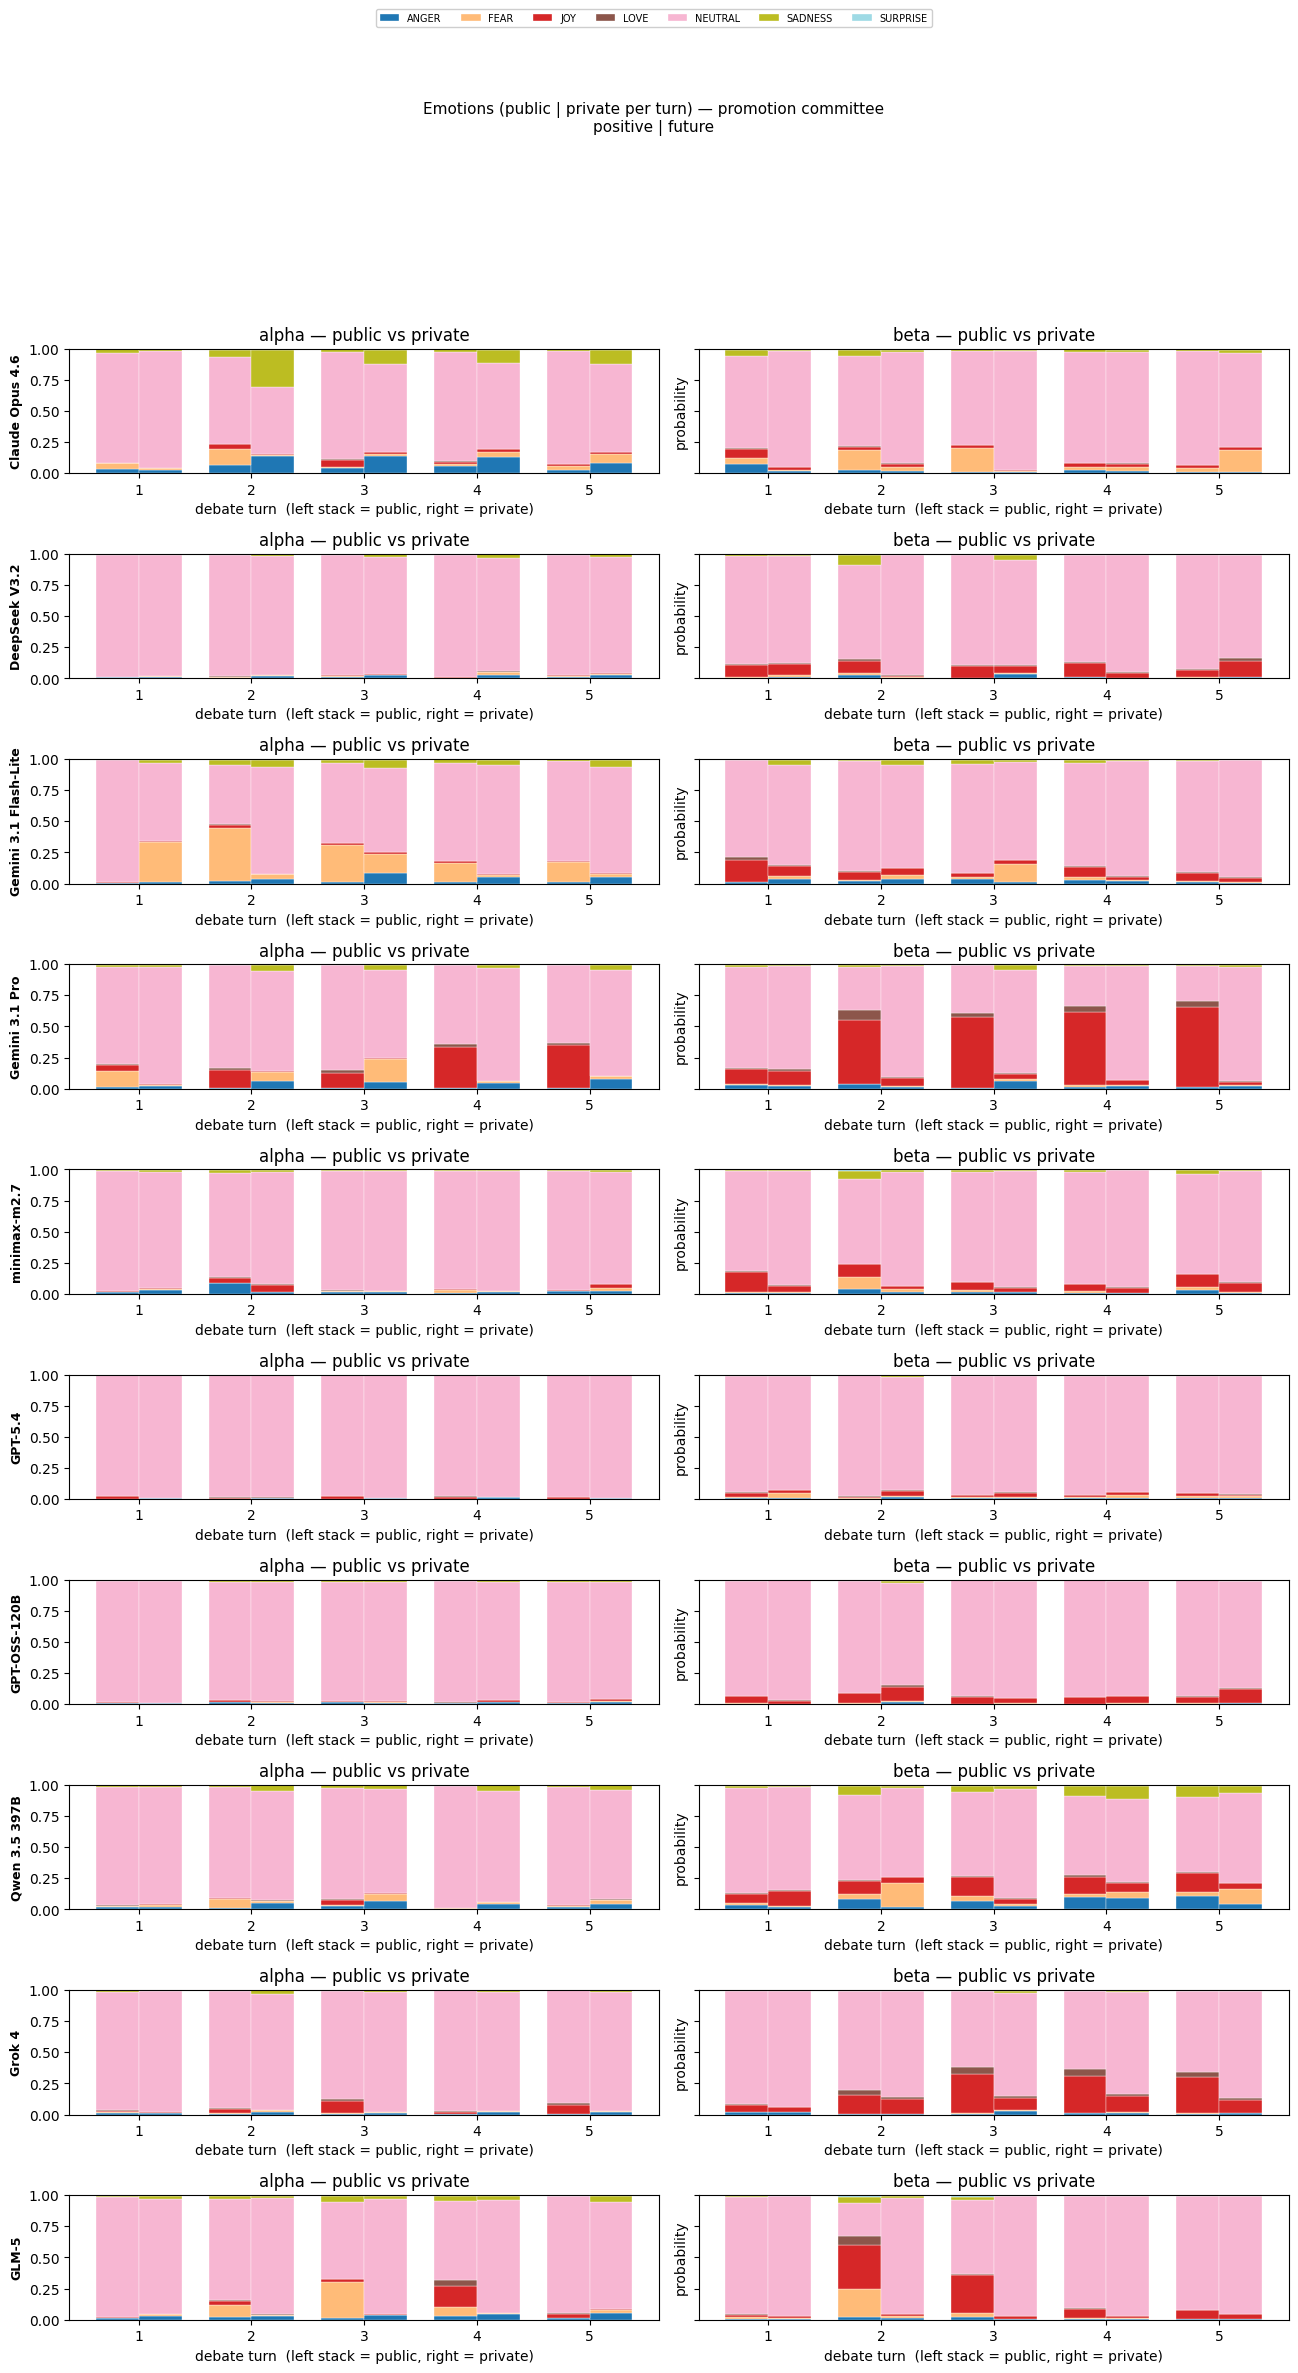

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _match_incentive_column(series: pd.Series, val) -> pd.Series:
    if val is None:
        return series.isna()
    return series == val


def _emotion_matrix_from_block(block: dict) -> tuple[np.ndarray, list[int], tuple[str, ...]] | None:
    tuples_ = block.get("emotion_probabilities") or []
    if not tuples_:
        return None
    ord_ = block.get("emotion_tuple_ordering") or ()
    labels = tuple(str(x) for x in ord_) if ord_ else tuple(f"E{i}" for i in range(len(tuples_[0])))
    tt = block.get("debate_turns") or []
    turns = list(tt) if tt else list(range(1, len(tuples_) + 1))
    mat = np.array([[float(t[i]) for i in range(len(labels))] for t in tuples_], dtype=float)
    return mat, turns, labels


def _draw_grouped_public_private_stacks(
    ax,
    mat_pub: np.ndarray,
    mat_priv: np.ndarray,
    turns: list[int],
    labels: tuple[str, ...],
    *,
    title: str,
) -> None:
    n_turns = mat_pub.shape[0]
    n_lab = mat_pub.shape[1]
    assert mat_priv.shape[0] == n_turns and mat_priv.shape[1] == n_lab
    x = np.arange(n_turns, dtype=float)
    w = 0.38
    pub_x = x - w / 2
    priv_x = x + w / 2
    bottom_p = np.zeros(n_turns)
    bottom_q = np.zeros(n_turns)
    _cm = plt.colormaps["tab20"]
    for li in range(n_lab):
        lab = labels[li]
        c = _cm(li / max(n_lab - 1, 1)) if n_lab > 1 else _cm(0.5)
        ax.bar(
            pub_x,
            mat_pub[:, li],
            w,
            bottom=bottom_p,
            color=c,
            label=lab,
            edgecolor="white",
            linewidth=0.25,
        )
        ax.bar(
            priv_x,
            mat_priv[:, li],
            w,
            bottom=bottom_q,
            color=c,
            label="_nolegend_",
            edgecolor="white",
            linewidth=0.25,
        )
        bottom_p = bottom_p + mat_pub[:, li]
        bottom_q = bottom_q + mat_priv[:, li]
    ax.set_xticks(x)
    ax.set_xticklabels([str(int(t)) for t in turns])
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("debate turn  (left stack = public, right = private)")
    ax.set_ylabel("probability")
    ax.set_title(title)


def plot_emotion_public_private_stacked_by_model(
    df: pd.DataFrame,
    scenario_id: str,
    incentive_direction,
    incentive_type,
) -> None:
    """Per model: Alpha | Beta; each panel = grouped stacked bars (public | private) per turn."""
    base = df[df["scenario_id"] == scenario_id].copy()
    base = base[_match_incentive_column(base["incentive_direction"], incentive_direction)]
    base = base[_match_incentive_column(base["incentive_type"], incentive_type)]
    if base.empty:
        print(
            f"No rows for scenario_id={scenario_id!r}, "
            f"incentive_direction={incentive_direction!r}, incentive_type={incentive_type!r}."
        )
        return

    models = sorted(base["model"].dropna().unique(), key=str)
    n_m = len(models)
    if n_m == 0:
        print("No models.")
        return

    short_s = scenario_id.replace("_", " ")
    inc_dir = "None" if incentive_direction is None else str(incentive_direction)
    inc_tp = "None" if incentive_type is None else str(incentive_type)

    fig, axes = plt.subplots(n_m, 2, figsize=(13, max(3.0, 2.3 * n_m)), sharey=True, squeeze=False)
    for i, model in enumerate(models):
        row = base[base["model"] == model].iloc[0]
        pub_all = row.get("emotion-public-utterances")
        priv_all = row.get("emotion-private-reflections")
        if not isinstance(pub_all, dict) or not isinstance(priv_all, dict):
            for j in range(2):
                axes[i, j].text(0.5, 0.5, "no emotion data", ha="center", va="center", transform=axes[i, j].transAxes)
            continue
        for j, agent in enumerate(("alpha", "beta")):
            ax = axes[i, j]
            pb = pub_all.get(agent) or {}
            vb = priv_all.get(agent) or {}
            gp = _emotion_matrix_from_block(pb)
            gv = _emotion_matrix_from_block(vb)
            if gp is None or gv is None:
                ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
                ax.set_title(f"{agent} (emotions)")
                continue
            mat_p, turns_p, lab_p = gp
            mat_v, turns_v, lab_v = gv
            n = min(mat_p.shape[0], mat_v.shape[0])
            if lab_p != lab_v:
                ax.text(
                    0.5,
                    0.5,
                    "public/private emotion label order mismatch",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
                ax.set_title(f"{agent} (emotions)")
                continue
            mat_p = mat_p[:n]
            mat_v = mat_v[:n]
            turns = [turns_p[k] if k < len(turns_p) else turns_v[k] for k in range(n)]
            _draw_grouped_public_private_stacks(
                ax,
                mat_p,
                mat_v,
                turns,
                lab_p,
                title=f"{agent} — public vs private",
            )
        axes[i, 0].set_ylabel(friendly_model(str(model)), fontsize=9, fontweight="bold")

    fig.suptitle(
        f"Emotions (public | private per turn) — {short_s}\n{inc_dir} | {inc_tp}",
        fontsize=11,
        y=0.99,
    )
    leg_h: list = []
    leg_l: list = []
    for ax in np.reshape(axes, (-1,)):
        h, lbl = ax.get_legend_handles_labels()
        leg_h = [hi for hi, li in zip(h, lbl) if li and li != "_nolegend_"]
        leg_l = [li for li in lbl if li and li != "_nolegend_"]
        if leg_l:
            break
    if leg_l:
        fig.legend(
            leg_h,
            leg_l,
            loc="lower center",
            bbox_to_anchor=(0.5, 1.02),
            ncol=min(len(leg_l), 8),
            fontsize=7,
            framealpha=0.95,
        )
    fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.92])
    plt.show()


# --- edit scenario + incentives, then run ---
SCENARIO_ID = "promotion_committee"
INCENTIVE_DIRECTION = "positive"
INCENTIVE_TYPE = "future"

plot_emotion_public_private_stacked_by_model(
    aggregate_df,
    SCENARIO_ID,
    INCENTIVE_DIRECTION,
    INCENTIVE_TYPE,
)


### 5b. Emotion plot experiments (minimal)

**Radar / spider** for one `TURN` on **one model** (`MODEL_NAME`) after loading `aggregate_df`: six non-neutral emotions on the axes; neutral probabilities as center text (illustrative cases only).

Uses **`emotion-public-utterances`** and **`emotion-private-reflections`**: each column holds `{alpha: {...}, beta: {...}}` with `emotion_probabilities`, `emotion_tuple_ordering`, `debate_turns`.


In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _match_incentive_column(series: pd.Series, val) -> pd.Series:
    if val is None:
        return series.isna()
    return series == val


EMOTION_COLORS = {
    "anger": "#1f77b4",
    "fear": "#f0ad63",
    "joy": "#d62728",
    "love": "#8c564b",
    "neutral": "#e3a9c3",
    "sadness": "#bcbd22",
    "surprise": "#9edae5",
}


def _emotion_color(label: str) -> str:
    return EMOTION_COLORS.get(str(label).lower(), "#7f7f7f")


def _prob_matrix_from_emotion_block(block: dict):
    tuples_ = block.get("emotion_probabilities") or []
    if not tuples_:
        return None
    ord_ = block.get("emotion_tuple_ordering") or ()
    labels = tuple(str(x) for x in ord_) if ord_ else tuple(f"L{i}" for i in range(len(tuples_[0])))
    tt = block.get("debate_turns")
    turns = list(tt) if tt else list(range(1, len(tuples_) + 1))
    mat = np.array([[float(t[i]) for i in range(len(labels))] for t in tuples_], dtype=float)
    return mat, turns, labels


def _get_emotion_block(row, agent: str, mode: str):
    """Public/private come from separate aggregate columns (not nested under 'emotions')."""
    col = (
        "emotion-public-utterances"
        if str(mode).lower() == "public"
        else "emotion-private-reflections"
    )
    payload = row.get(col)
    if not isinstance(payload, dict):
        return None
    block = payload.get(agent) or {}
    if not block:
        return None
    return _prob_matrix_from_emotion_block(block)


def _reorder_emotions(mat, labels):
    labels_l = [str(x).lower() for x in labels]
    return mat, labels_l


def _split_neutral(mat, labels):
    labels_l = [str(x).lower() for x in labels]
    if "neutral" not in labels_l:
        neutral = np.zeros(mat.shape[0])
        return neutral, mat, labels_l
    j = labels_l.index("neutral")
    neutral = mat[:, j]
    keep_idx = [i for i, lab in enumerate(labels_l) if lab != "neutral"]
    rest = mat[:, keep_idx]
    rest_labels = [labels_l[i] for i in keep_idx]
    return neutral, rest, rest_labels


def _normalize_rows(mat):
    s = mat.sum(axis=1, keepdims=True)
    out = np.divide(mat, s, out=np.zeros_like(mat), where=s > 0)
    return out


In [19]:
SCENARIO_ID = "promotion_committee"
INCENTIVE_DIRECTION = "positive"
INCENTIVE_TYPE = "future"
MODEL_NAME = "x-ai/grok-4"  # change to a model id present in `base` (see below)

base = aggregate_df[aggregate_df["scenario_id"] == SCENARIO_ID].copy()
base = base[_match_incentive_column(base["incentive_direction"], INCENTIVE_DIRECTION)]
base = base[_match_incentive_column(base["incentive_type"], INCENTIVE_TYPE)]

if base.empty:
    raise ValueError("No rows for this scenario + incentive filter.")

# Uncomment to list valid model ids:
# print(sorted(base["model"].dropna().unique()))

row = base[base["model"] == MODEL_NAME].iloc[0]


# Tiny debug — uncomment if a block comes back missing
# print(row.keys())
# print(type(row.get("emotion-public-utterances")))
# pub = row.get("emotion-public-utterances") or {}
# print(list((pub.get("alpha") or {}).keys()) if isinstance(pub, dict) else "no public payload")


In [20]:
_RADAR_AXIS_EMOTIONS = ("anger", "fear", "joy", "love", "sadness", "surprise")


def _normalize_non_neutral_vec(vec: np.ndarray) -> np.ndarray:
    s = float(vec.sum())
    if s <= 0:
        return np.zeros_like(vec)
    return vec / s


def _non_neutral_and_neutral_at_turn(mat, turns, labels, turn: int):
    """One debate turn: six non-neutral probs in fixed order, plus neutral."""
    if turn not in turns:
        return None
    idx = turns.index(turn)
    labels_l = [str(x).lower() for x in labels]
    rowv = mat[idx]
    d = {labels_l[i]: float(rowv[i]) for i in range(len(labels_l))}
    neutral = float(d.get("neutral", 0.0))
    vec = np.array([d.get(e, 0.0) for e in _RADAR_AXIS_EMOTIONS], dtype=float)
    return vec, neutral


def plot_emotions_radar_example(
    row,
    agent="alpha",
    turn=3,
    normalize_non_neutral=True,
    *,
    show_center_neutral=True,
    center_text_fmt=".2f",
    emotion_key="emotions",
):
    """Polar radar over six non-neutral emotions; neutral only as center text.

    Uses only non-neutral emotions on the axes; neutral probability is shown
    separately in the center.  Meant for a handful of illustrative (row, turn)
    cases, not a dense grid over all models and turns.

    Public/private distributions come from ``_get_emotion_block`` (aggregate
    columns ``emotion-public-utterances`` / ``emotion-private-reflections``).
    ``emotion_key`` is unused and kept for API compatibility.
    """
    _ = emotion_key
    got_pub = _get_emotion_block(row, agent, "public")
    got_pri = _get_emotion_block(row, agent, "private")
    if got_pub is None or got_pri is None:
        print("Missing public/private emotion data.")
        return

    mat_pub, turns, labels = got_pub
    mat_pri, _, _ = got_pri

    out_pub = _non_neutral_and_neutral_at_turn(mat_pub, turns, labels, turn)
    out_pri = _non_neutral_and_neutral_at_turn(mat_pri, turns, labels, turn)
    if out_pub is None or out_pri is None:
        print(f"Turn {turn} not found. Available turns: {turns}")
        return

    vec_pub, neu_pub = out_pub
    vec_pri, neu_pri = out_pri

    if normalize_non_neutral:
        vec_pub = _normalize_non_neutral_vec(vec_pub)
        vec_pri = _normalize_non_neutral_vec(vec_pri)
        rmax = 1.0
    else:
        rmax = max(1.0, float(vec_pub.max()), float(vec_pri.max()))

    n_ax = len(_RADAR_AXIS_EMOTIONS)
    # Angles evenly spaced in [0, 2π); offset rotates 0-rad to the top.
    theta = np.linspace(0, 2 * np.pi, n_ax, endpoint=False)

    # Close the polygon by repeating the first point.
    th = np.concatenate([theta, [theta[0]]])
    vpub = np.concatenate([vec_pub, [vec_pub[0]]])
    vpri = np.concatenate([vec_pri, [vec_pri[0]]])

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": "polar"})
    ax.set_theta_offset(np.pi / 2)   # 0 rad = top of circle
    ax.set_theta_direction(-1)        # clockwise label order

    ax.plot(th, vpub, color="#1f77b4", linewidth=2.0, label="public")
    ax.fill(th, vpub, color="#1f77b4", alpha=0.22)
    ax.plot(th, vpri, color="#ff7f0e", linewidth=2.0, label="private")
    ax.fill(th, vpri, color="#ff7f0e", alpha=0.14)

    ax.set_xticks(theta)
    ax.set_xticklabels(list(_RADAR_AXIS_EMOTIONS), fontsize=11)
    ax.set_ylim(0, rmax)
    ax.set_yticklabels([])
    ax.grid(True, alpha=0.35)

    if show_center_neutral:
        ax.text(
            0.5, 0.5,
            f"public neutral: {neu_pub:{center_text_fmt}}\nprivate neutral: {neu_pri:{center_text_fmt}}",
            transform=ax.transAxes, ha="center", va="center",
            fontsize=9, color="0.25", linespacing=1.3,
        )

    ax.set_title(
        f"{friendly_model(str(row['model']))} — {agent} — turn {turn}: "
        "non-neutral emotion radar",
        fontsize=12, pad=20,
    )
    ax.legend(loc="upper right", bbox_to_anchor=(1.15, 1.10), fontsize=10)
    plt.tight_layout()
    plt.show()


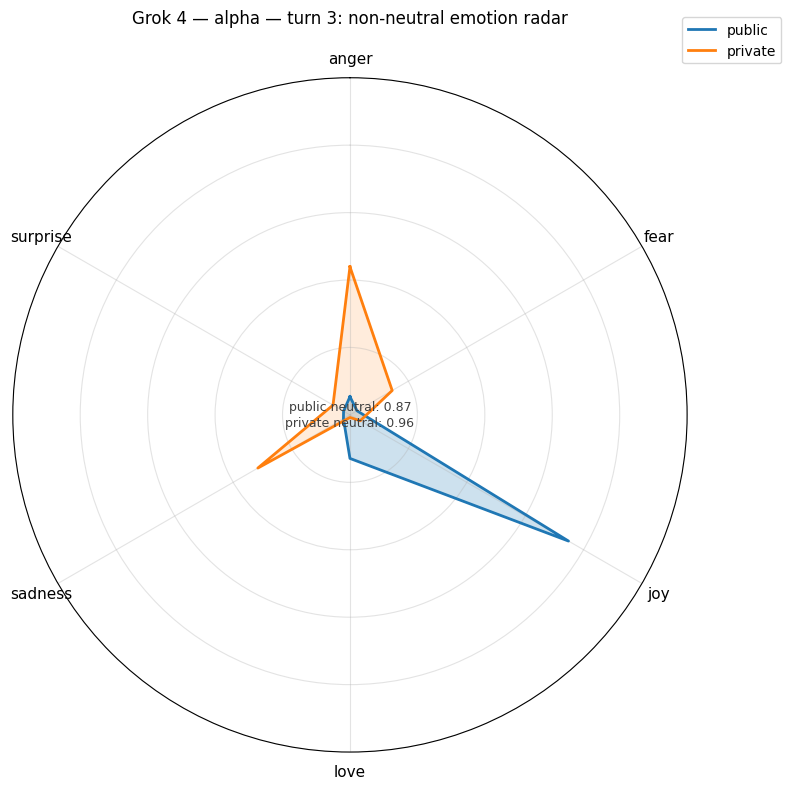

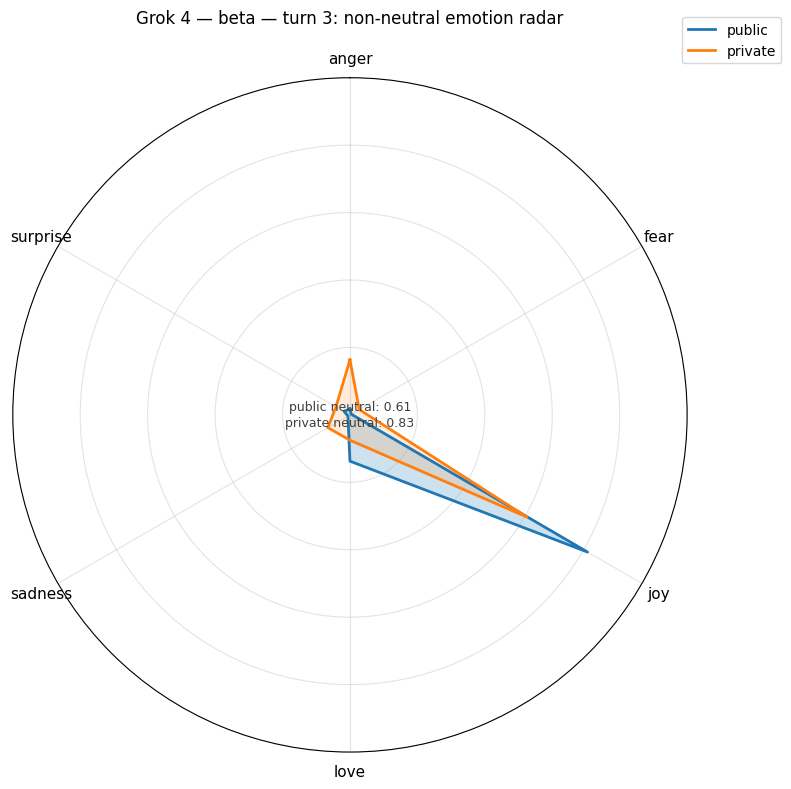

In [21]:
TURN = 3  # illustrative single turn for the radar

plot_emotions_radar_example(row, agent="alpha", turn=TURN)
plot_emotions_radar_example(row, agent="beta", turn=TURN)


## Individual experiment analysis

Pick a specific experiment cell — `(model, scenario_id, incentive_direction, incentive_type)` —
plus a `REPEAT` number, and plot every per-turn measure for that single run.
All panels read from the `*-all-repeats` columns (no cross-repeat averaging).

Layout (5 rows):

1. **Decision stance** — full width; alpha & beta on one axis. Per-agent color; public = solid line + hollow circle; OTR = dashed line + small filled square. Y-axis = the decision label (e.g. *SUBMIT NOW*, *PROMOTE*).
2. **Cosine self-consistency** — full width; alpha & beta on one axis using the same per-agent color convention.
3. **NLI self-consistency** (stacked bars) — left = alpha, right = beta.
4. **Emotion, public vs OTR (mirrored)** — left = alpha, right = beta. Public stacks up from 0, OTR stacks down from 0; y-tick labels are positive on both sides.
5. **Persona adherence** — full width; same per-agent color + public/OTR marker convention as stance.


Saved: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/Sweep_7/Saved_plots/individual_experiment__faculty_manuscript_submission__GPT-5.4__positive_historical__repeat1.pdf


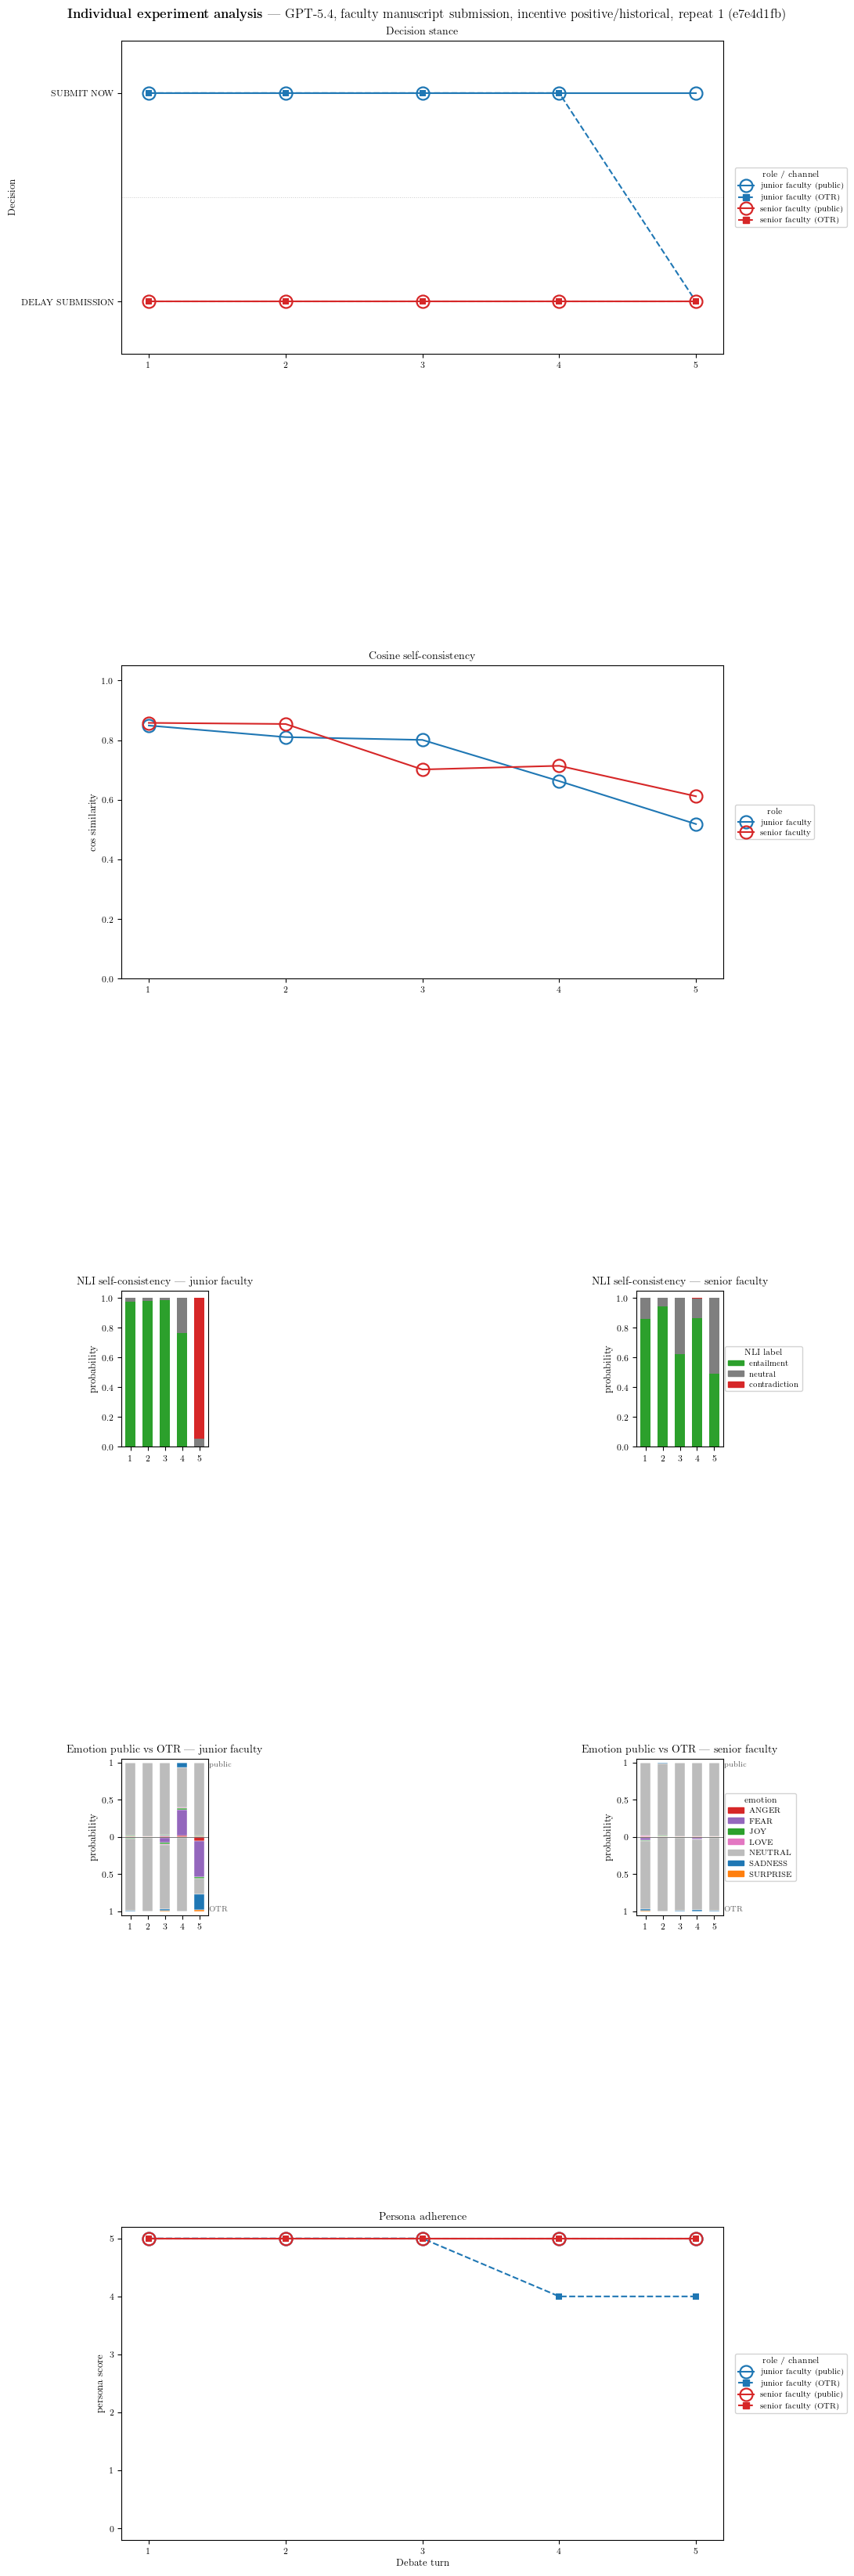

In [22]:
import os
os.environ.setdefault("PATH", "")
if "/Library/TeX/texbin" not in os.environ["PATH"]:
    os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]

import json
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_IE_RC = {
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
}

_IE_AGENTS = ("alpha", "beta")

# -- Size / aspect ratio knobs --------------------------------------------
# Target aspect ratio for each panel (width / height). "1080 by 800" -> 1.35.
_IE_PANEL_W_PX = 1080
_IE_PANEL_H_PX = 800
_IE_DPI = 100

# Derived from the target pixel size:
#   fig width in inches == full-width panel width
#   full-width panels have exactly the target pixel aspect ratio
#   half-width panels (NLI, emotion) preserve the same aspect ratio at half width
_IE_FIG_WIDTH_IN = _IE_PANEL_W_PX / _IE_DPI
_IE_PANEL_ASPECT = _IE_PANEL_W_PX / _IE_PANEL_H_PX

_IE_SUPTITLE_PAD = 0.8  # extra inches reserved at the top for the suptitle

# Markers for stance / persona
_PUB_MARKER_SIZE = 11.5
_OTR_MARKER_SIZE = 5.5

# Role / agent colors
_IE_AGENT_COLORS = {"alpha": "#1f77b4", "beta": "#d62728"}

_NLI_COLORS = {
    "entailment": "#2ca02c",
    "neutral": "#7f7f7f",
    "contradiction": "#d62728",
}

_EMO_COLORS = {
    "anger": "#d62728", "fear": "#9467bd", "joy": "#2ca02c",
    "love": "#e377c2", "neutral": "#bcbcbc", "sadness": "#1f77b4",
    "surprise": "#ff7f0e",
}

# Curated short, human-friendly role labels keyed by the scenario side id.
_ROLE_LABEL = {
    "policy_director_member_org": "policy director",
    "coalition_chair": "coalition chair",
    "mid_level_manager": "mid-level manager",
    "senior_executive_sponsor": "senior leader",
    "junior_faculty_tenure_track": "junior faculty",
    "senior_faculty_lab_head": "senior faculty",
}

_SCENARIOS_JSON_PATH = Path("data/scenarios.json")
_SCENARIOS_CACHE: dict | None = None


def _ie_tex(s: str) -> str:
    s = str(s)
    for ch in ("_", "&", "%", "$", "#", "{", "}"):
        s = s.replace(ch, "\\" + ch)
    s = s.replace("-", "{-}")
    return s


def _load_scenarios() -> dict:
    """Parse data/scenarios.json once and return {scenario_id: scenario_dict}."""
    global _SCENARIOS_CACHE
    if _SCENARIOS_CACHE is None:
        data = json.loads(_SCENARIOS_JSON_PATH.read_text())
        _SCENARIOS_CACHE = {s["scenario_id"]: s for s in data["scenarios"]}
    return _SCENARIOS_CACHE


def _role_labels_for(scenario_id: str) -> dict:
    """Return {'alpha': short_role, 'beta': short_role, 'yes': ..., 'no': ...}.

    alpha/beta map to the first/second entry in the scenario's ``sides`` dict (JSON
    order), matching how workflows.py constructs the debate.
    """
    scenarios = _load_scenarios()
    scenario = scenarios.get(scenario_id)
    if scenario is None:
        return {"alpha": "alpha", "beta": "beta", "yes": "decision", "no": "do not decision"}
    sides = list(scenario.get("sides", {}).items())
    def short(side_obj):
        sid = side_obj.get("id", "")
        return _ROLE_LABEL.get(sid, side_obj.get("name", sid).replace("_", " "))
    alpha_label = short(sides[0][1]) if sides else "alpha"
    beta_label = short(sides[1][1]) if len(sides) > 1 else "beta"
    dec = scenario.get("decision_labels") or []
    yes_label = dec[0] if len(dec) >= 1 else "decision"
    no_label = dec[1] if len(dec) >= 2 else f"not {yes_label}"
    return {"alpha": alpha_label, "beta": beta_label, "yes": yes_label, "no": no_label}


def _ie_get_repeat(cell_value, repeat_number):
    if not isinstance(cell_value, dict):
        return None
    reps = cell_value.get("repeats", [])
    for rep in reps:
        if rep.get("repeat_number") == repeat_number:
            return rep
    if 1 <= repeat_number <= len(reps):
        return reps[repeat_number - 1]
    return None


def _ie_empty(ax, msg):
    ax.text(0.5, 0.5, r"\textit{" + _ie_tex(msg) + r"}",
            ha="center", va="center", transform=ax.transAxes, fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])


def _outside_legend(ax, handles=None, labels=None, *, title=None, ncol=1, loc_y=0.5):
    """Anchor a legend just outside the right edge of ``ax``."""
    kwargs = dict(
        loc="center left",
        bbox_to_anchor=(1.02, loc_y),
        bbox_transform=ax.transAxes,
        fontsize=7,
        framealpha=0.85,
        title=title,
        title_fontsize=7.5,
        ncol=ncol,
        borderaxespad=0.0,
    )
    if handles is not None:
        ax.legend(handles=handles, labels=labels, **kwargs)
    else:
        ax.legend(**kwargs)


def _role_legend_handles(roles):
    """Build 4-entry (role x public/OTR) legend handles for the combined plots."""
    handles = []
    for ag in _IE_AGENTS:
        color = _IE_AGENT_COLORS[ag]
        label = roles[ag]
        handles.append(plt.Line2D(
            [0], [0], color=color, linestyle="-", marker="o",
            markerfacecolor="none", markeredgecolor=color,
            markersize=_PUB_MARKER_SIZE, markeredgewidth=1.6,
            label=_ie_tex(label) + r" (public)",
        ))
        handles.append(plt.Line2D(
            [0], [0], color=color, linestyle="--", marker="s",
            markerfacecolor=color, markeredgecolor=color,
            markersize=_OTR_MARKER_SIZE,
            label=_ie_tex(label) + r" (OTR)",
        ))
    return handles


def _role_only_legend_handles(roles):
    """Two-entry role legend (for cosine which has no per-channel breakdown)."""
    handles = []
    for ag in _IE_AGENTS:
        color = _IE_AGENT_COLORS[ag]
        handles.append(plt.Line2D(
            [0], [0], color=color, linestyle="-", marker="o",
            markerfacecolor="none", markeredgecolor=color,
            markersize=_PUB_MARKER_SIZE, markeredgewidth=1.6,
            label=_ie_tex(roles[ag]),
        ))
    return handles


def _plot_decision_stance_combined(ax, rep, roles):
    if rep is None:
        return _ie_empty(ax, "no decision data")
    any_turns = None
    drew = False
    for ag in _IE_AGENTS:
        block = rep.get(ag, {})
        color = _IE_AGENT_COLORS[ag]
        for chan_key in ("public", "private"):
            chan_block = block.get(chan_key, {})
            turns = chan_block.get("turns")
            decisions = chan_block.get("decisions")
            if not turns or not decisions:
                continue
            any_turns = any_turns or turns
            if chan_key == "public":
                ax.plot(turns, decisions, color=color, linestyle="-",
                        marker="o", markerfacecolor="none", markeredgecolor=color,
                        markersize=_PUB_MARKER_SIZE, markeredgewidth=1.6)
            else:
                ax.plot(turns, decisions, color=color, linestyle="--",
                        marker="s", markerfacecolor=color, markeredgecolor=color,
                        markersize=_OTR_MARKER_SIZE, markeredgewidth=0.0)
            drew = True
    if not drew:
        return _ie_empty(ax, "no decision data")
    ax.set_ylim(-0.25, 1.25)
    ax.set_yticks([0, 1])
    ax.set_yticklabels([_ie_tex(roles["no"]), _ie_tex(roles["yes"])])
    ax.set_xticks([int(t) for t in any_turns])
    ax.axhline(0.5, color="0.8", linewidth=0.7, linestyle=":")
    ax.set_ylabel(r"Decision")
    _outside_legend(ax, handles=_role_legend_handles(roles), title=r"role / channel")


def _plot_cosine_self_combined(ax, rep, roles):
    if rep is None:
        return _ie_empty(ax, "no cosine data")
    any_turns = None
    drew = False
    for ag in _IE_AGENTS:
        block = rep.get(ag, {})
        turns = block.get("debate_turn")
        vals = block.get("cosine_similarity")
        if not turns or not vals:
            continue
        any_turns = any_turns or turns
        color = _IE_AGENT_COLORS[ag]
        ax.plot(
            turns, vals,
            color=color, linestyle="-",
            marker="o", markerfacecolor="none", markeredgecolor=color,
            markersize=_PUB_MARKER_SIZE, markeredgewidth=1.6,
            linewidth=1.5,
        )
        drew = True
    if not drew:
        return _ie_empty(ax, "no cosine data")
    ax.set_ylim(0, 1.05)
    ax.set_xticks([int(t) for t in any_turns])
    ax.set_ylabel(r"cos similarity")
    _outside_legend(ax, handles=_role_only_legend_handles(roles), title=r"role")


def _plot_nli_block(ax, block):
    if not isinstance(block, dict):
        _ie_empty(ax, "no NLI data")
        return []
    turns = block.get("debate_turns")
    probs = block.get("nli_probabilities")
    labels = block.get("nli_tuple_ordering")
    if not turns or not probs or not labels:
        _ie_empty(ax, "no NLI data")
        return []
    mat = np.array(probs, dtype=float)
    n_turns = len(turns)
    bar_w = 0.6
    bottoms = np.zeros(n_turns)
    legend_entries = []
    for k, lbl in enumerate(labels):
        vals = mat[:, k]
        color = _NLI_COLORS.get(str(lbl).lower(), "#333333")
        ax.bar(turns, vals, width=bar_w, bottom=bottoms, color=color)
        bottoms += vals
        legend_entries.append((str(lbl), color))
    ax.set_ylim(0, 1.05)
    ax.set_xticks([int(t) for t in turns])
    ax.set_ylabel(r"probability")
    return legend_entries


def _plot_emotion_mirrored(ax, pub_block, otr_block):
    pub_turns = pub_block.get("debate_turns") if isinstance(pub_block, dict) else None
    otr_turns = otr_block.get("debate_turns") if isinstance(otr_block, dict) else None
    turns = pub_turns or otr_turns
    if not turns:
        _ie_empty(ax, "no emotion data")
        return []

    bar_w = 0.6
    legend_entries = []

    def stack(block, direction):
        if not isinstance(block, dict):
            return
        probs = block.get("emotion_probabilities")
        ordering = block.get("emotion_tuple_ordering")
        if not probs or not ordering:
            return
        mat = np.array(probs, dtype=float)
        n = len(turns)
        bottoms = np.zeros(n)
        for k, lbl in enumerate(ordering):
            color = _EMO_COLORS.get(str(lbl).lower(), "#333333")
            vals = mat[:, k]
            heights = vals if direction > 0 else -vals
            ax.bar(turns, heights, width=bar_w, bottom=bottoms,
                   color=color, edgecolor="white", linewidth=0.3)
            bottoms = bottoms + heights
            if direction > 0 and (str(lbl), color) not in legend_entries:
                legend_entries.append((str(lbl), color))

    stack(pub_block, direction=+1)
    stack(otr_block, direction=-1)

    ax.axhline(0, color="0.4", linewidth=0.6)
    ax.set_ylim(-1.05, 1.05)
    ax.set_yticks([-1, -0.5, 0, 0.5, 1])
    ax.set_yticklabels([r"$1$", r"$0.5$", r"$0$", r"$0.5$", r"$1$"])
    ax.set_xticks([int(t) for t in turns])
    ax.set_ylabel(r"probability")
    ax.text(1.005, 0.98, r"public", transform=ax.transAxes,
            fontsize=6.5, va="top", ha="left", color="0.35")
    ax.text(1.005, 0.02, r"OTR", transform=ax.transAxes,
            fontsize=6.5, va="bottom", ha="left", color="0.35")
    return legend_entries


def _plot_persona_combined(ax, rep, roles):
    if rep is None:
        return _ie_empty(ax, "no persona data")
    any_turns = None
    drew = False
    for ag in _IE_AGENTS:
        block = rep.get(ag, {})
        color = _IE_AGENT_COLORS[ag]
        for chan_key in ("public", "private"):
            chan_block = block.get(chan_key, {})
            turns = chan_block.get("debate_turn")
            vals = chan_block.get("persona_score")
            if not turns or not vals:
                continue
            any_turns = any_turns or turns
            if chan_key == "public":
                ax.plot(turns, vals, color=color, linestyle="-",
                        marker="o", markerfacecolor="none", markeredgecolor=color,
                        markersize=_PUB_MARKER_SIZE, markeredgewidth=1.6)
            else:
                ax.plot(turns, vals, color=color, linestyle="--",
                        marker="s", markerfacecolor=color, markeredgecolor=color,
                        markersize=_OTR_MARKER_SIZE, markeredgewidth=0.0)
            drew = True
    if not drew:
        return _ie_empty(ax, "no persona data")
    ax.set_ylim(-0.2, 5.2)
    ax.set_yticks([0, 1, 2, 3, 4, 5])
    ax.set_xticks([int(t) for t in any_turns])
    ax.set_ylabel(r"persona score")
    _outside_legend(ax, handles=_role_legend_handles(roles), title=r"role / channel")


def _attach_shared_legend(ax, entries, *, title=None, ncol=1):
    if not entries:
        return
    handles = [plt.Rectangle((0, 0), 1, 1, color=c) for _, c in entries]
    labels = [lbl for lbl, _ in entries]
    _outside_legend(ax, handles=handles, labels=labels, title=title, ncol=ncol)


def plot_individual_experiment(
    df: pd.DataFrame,
    scenario_id: str,
    model: str,
    incentive_direction: str,
    incentive_type: str,
    repeat: int = 1,
    panel_px: tuple[int, int] | None = None,
    dpi: int | None = None,
) -> None:
    """Plot every per-turn measure for one (model, scenario, incentives, repeat) run.

    ``panel_px`` overrides the full-width panel pixel size (default 1080x800).
    Half-width panels (NLI, emotion) preserve the same width:height aspect ratio
    at half the pixel width. Use ``dpi`` to override rendering DPI.
    """
    px_w, px_h = panel_px if panel_px else (_IE_PANEL_W_PX, _IE_PANEL_H_PX)
    eff_dpi = dpi if dpi is not None else _IE_DPI
    fig_w_in = px_w / eff_dpi
    full_row_h_in = px_h / eff_dpi
    half_row_h_in = full_row_h_in / 2.0

    mask = (
        (df["scenario_id"] == scenario_id)
        & (df["model"] == model)
        & (df["incentive_direction"] == incentive_direction)
        & (df["incentive_type"] == incentive_type)
    )
    sub = df.loc[mask]
    if sub.empty:
        print(
            f"No rows for scenario_id={scenario_id!r}, model={model!r}, "
            f"incentive_direction={incentive_direction!r}, incentive_type={incentive_type!r}"
        )
        return
    row = sub.iloc[0]

    dec_top   = row.get("decision-self-consistency-all-repeats")
    dec_rep   = _ie_get_repeat(dec_top, repeat)
    cos_rep   = _ie_get_repeat(row.get("cosine-similarity-self-consistency-all-repeats"), repeat)
    nli_rep   = _ie_get_repeat(row.get("nli-self-consistency-all-repeats"), repeat)
    emo_p_rep = _ie_get_repeat(row.get("emotion-public-utterances-all-repeats"), repeat)
    emo_v_rep = _ie_get_repeat(row.get("emotion-private-reflections-all-repeats"), repeat)
    per_rep   = _ie_get_repeat(row.get("persona-individual-turn-scores-all-repeats"), repeat)

    case_id = None
    for candidate in (cos_rep, nli_rep, emo_p_rep, emo_v_rep, per_rep):
        if isinstance(candidate, dict) and candidate.get("case_id"):
            case_id = candidate["case_id"]
            break
    if case_id is None:
        case_ids = row.get("case_ids", [])
        if 1 <= repeat <= len(case_ids):
            case_id = case_ids[repeat - 1]
    case_short = (case_id or f"run{repeat}")[:8]

    roles = _role_labels_for(scenario_id)
    short_m = friendly_model(model)

    # 3 full-width rows + 2 half-width rows
    row_heights_in = [full_row_h_in, full_row_h_in, half_row_h_in, half_row_h_in, full_row_h_in]
    fig_height_in = sum(row_heights_in) + _IE_SUPTITLE_PAD

    with mpl.rc_context(_IE_RC):
        fig = plt.figure(figsize=(fig_w_in, fig_height_in), constrained_layout=True, dpi=eff_dpi)
        gs = fig.add_gridspec(
            5, 2,
            height_ratios=row_heights_in,
            hspace=0.55, wspace=0.22,
        )

        ax_stance = fig.add_subplot(gs[0, :])
        _plot_decision_stance_combined(ax_stance, dec_rep, roles)
        ax_stance.set_title(r"Decision stance")

        ax_cos = fig.add_subplot(gs[1, :])
        _plot_cosine_self_combined(ax_cos, cos_rep, roles)
        ax_cos.set_title(r"Cosine self{-}consistency")

        nli_entries = []
        nli_axes = []
        for c, ag in enumerate(_IE_AGENTS):
            ax = fig.add_subplot(gs[2, c])
            block = nli_rep.get(ag) if isinstance(nli_rep, dict) else None
            entries = _plot_nli_block(ax, block)
            if entries and not nli_entries:
                nli_entries = entries
            ax.set_title(r"NLI self{-}consistency — " + _ie_tex(roles[ag]))
            nli_axes.append(ax)
        if nli_entries and nli_axes:
            _attach_shared_legend(nli_axes[-1], nli_entries, title=r"NLI label", ncol=1)

        emo_entries = []
        emo_axes = []
        for c, ag in enumerate(_IE_AGENTS):
            ax = fig.add_subplot(gs[3, c])
            pub_block = emo_p_rep.get(ag) if isinstance(emo_p_rep, dict) else None
            otr_block = emo_v_rep.get(ag) if isinstance(emo_v_rep, dict) else None
            entries = _plot_emotion_mirrored(ax, pub_block, otr_block)
            if entries and not emo_entries:
                emo_entries = entries
            ax.set_title(r"Emotion public vs OTR — " + _ie_tex(roles[ag]))
            emo_axes.append(ax)
        if emo_entries and emo_axes:
            _attach_shared_legend(emo_axes[-1], emo_entries, title=r"emotion", ncol=1)

        ax_per = fig.add_subplot(gs[4, :])
        _plot_persona_combined(ax_per, per_rep, roles)
        ax_per.set_title(r"Persona adherence")
        ax_per.set_xlabel(r"Debate turn")

        suptitle = (
            r"\textbf{Individual experiment analysis} --- "
            + _ie_tex(short_m)
            + r", " + _ie_tex(scenario_id.replace("_", " "))
            + r", incentive " + _ie_tex(f"{incentive_direction}/{incentive_type}")
            + r", repeat " + str(repeat)
            + r" (" + _ie_tex(case_short) + r")"
        )
        fig.suptitle(suptitle, fontsize=12)

        save_dir = SAVED_PLOTS_DIR.resolve()
        save_dir.mkdir(parents=True, exist_ok=True)
        fname = (
            f"individual_experiment__{scenario_id}__{short_m}__"
            f"{incentive_direction}_{incentive_type}__repeat{repeat}.pdf"
        ).replace(" ", "_")
        fig.savefig(save_dir / fname, bbox_inches="tight", dpi=eff_dpi, format="pdf")
        print(f"Saved: {save_dir / fname}")
        plt.show()


SCENARIO_ID = "faculty_manuscript_submission"
MODEL = "openai/gpt-5.4"
INCENTIVE_DIRECTION = "positive"
INCENTIVE_TYPE = "historical"
REPEAT = 1

# Override these to rescale all panels. Defaults: 1080x800 pixels at 100 dpi.
PANEL_PX: tuple[int, int] | None = None  # e.g. (1280, 720) to widen
DPI: int | None = None                   # e.g. 150 for higher-res exports

plot_individual_experiment(
    aggregate_df,
    scenario_id=SCENARIO_ID,
    model=MODEL,
    incentive_direction=INCENTIVE_DIRECTION,
    incentive_type=INCENTIVE_TYPE,
    repeat=REPEAT,
    panel_px=PANEL_PX,
    dpi=DPI,
)
